# Repair Order Analysis

## Overview

Bundled with this notebook is a dataset called `repair_orders.parquet`. Inside, you'll find a denormalized snapshot of repair orders (ROs) for vehicles and the associated services performed on those vehicles. To summarize the schema:

| column | description |
| --- | --- |
| `repair_order_id` | An integer uniquely identifying a Repair Order |
| `repair_order_total_usd` | The total cost of the repair order paid by the customer |
| `service_id` | An integer uniquely identifying a service performed for the vehicle |
| `service_item_code` | A descriptive text code representing a line item (service item) performed as part of the service |
| `service_item_type` | A "type" of the service item. E.g. "parts," "labor," "fee" |
| `service_category` | A descriptive text category logically grouping a set of service items |
| `service_item_quantity` | A quantity/count of the service item |
| `service_item_labor_hours` | The amount of labor hours required for the service item |
| `service_item_price_usd` | The service item price in dollars |
| `fleet_id` | An integer uniquely identifying the fleet (a company) that owns the vehicle |
| `fleet_name` | The name of the fleet company |
| `vehicle_id` | An integer uniquely identifying a vehicle |
| `vin` | A vehicle identification number |
| `vehicle_make` | A vehicle make (e.g., FORD) |
| `vehicle_model` | A vehicle model |
| `vehicle_year` | A vehicle's manufacturing year |
| `mileage_in` | A vehicle's mileage at intake for the repair order |
| `shop_name` | A name of the repair shop in which the services are performed |
| `shop_state` | The repair shop's state |
| `shop_city` | The repair shop's city |

Repair orders and their associated data are generated by humans, so in some cases the data may be inaccurate to some degree. That said, we can assume:

1. That `repair_order_total_usd` is what the customer paid for the repair order.
2. That `vehicle_id`, `fleet_id`, and `shop_id` uniquely and consistently represent vehicles, fleets, and shops, respectively.

## Analysis

Your task is to mine this dataset for interesting information. We'd like to keep this open-ended to facilitate discussion during your in-person interview. In general, we are interested in answers to questions such as the following:

1. What are the variances in price for specific service item codes? What about service categories? Are some service items more predictable than others?
2. Do some fleets pay more than others for the same services?
3. Are some shops a very good value for certain services?
4. Is there a correlation between vehicle make/model and certain types of repair costs?
5. Customers may be given an estimate consisting of vehicle details and a list of service item codes. Is it possible to predict the cost of the overall repair order? With how much uncertainty?
6. What data do you think we could collect or improve to make cost predictions better?
7. What types of models do you recommend for making price predictions?
8. What kinds of service items frequently occur together?
9. Are some shops better than others at reporting service item prices?

Be creative but specific in your analyses. For example, if you tell us that all of the above questions are impossible to answer, we'd like to know why, with sufficient evidence to back it up. We'd also like to know what we would need to do to make the questions possible to answer.

In [42]:
%matplotlib inline
import os
import warnings
from itertools import combinations

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

CHARTS_DIR = "./charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

## Data Loading & Cleaning

In [43]:
df = pd.read_parquet("./repair_orders.parquet")
print(f"Loaded {len(df):,} rows x {len(df.columns)} columns")
print(f"  Unique repair orders: {df['repair_order_id'].nunique():,}")
print(f"  Unique services:      {df['service_id'].nunique():,}")
print(f"  Unique vehicles:      {df['vehicle_id'].nunique():,}")
print(f"  Unique fleets:        {df['fleet_id'].nunique():,}")
print(f"  Unique shops:         {df['shop_name'].dropna().nunique()}")

df.head()

Loaded 141,376 rows x 20 columns
  Unique repair orders: 35,361
  Unique services:      64,527
  Unique vehicles:      10,360
  Unique fleets:        781
  Unique shops:         148


,repair_order_id,service_id,vehicle_id,fleet_id,fleet_name,vin,vehicle_make,vehicle_model,vehicle_year,mileage_in,shop_name,shop_state,shop_city,repair_order_total_usd,service_item_code,service_category,service_item_type,service_item_quantity,service_item_labor_hours,service_item_price_usd
0,1,9442,1208,172,Halcyon Cargo Co,8EHZHTTGLPRWP7MBG,FORD,E-450,2019,53147,City Autoworks Inc,IL,Edwardsville,113.40,diagnostics,OTHER,labor,1.0,1.0,113.40
1,2,9474,1680,163,Magnolia Trucking Group,GAAUR6GPG6K2H1FRY,FORD,Transit,2021,88936,City Autoworks Inc,IL,Edwardsville,105.27,brake-inspection,BRAKE_PADS,labor,1.0,1.0,33.55
2,2,9475,1680,163,Magnolia Trucking Group,GAAUR6GPG6K2H1FRY,FORD,Transit,2021,88936,City Autoworks Inc,IL,Edwardsville,105.27,air-filter-element,OTHER,labor,1.0,1.0,56.70
3,2,9475,1680,163,Magnolia Trucking Group,GAAUR6GPG6K2H1FRY,FORD,Transit,2021,88936,City Autoworks Inc,IL,Edwardsville,105.27,air-filter-element,OTHER,part,1.0,0.0,15.02
4,3,9478,1673,163,Magnolia Trucking Group,PBYCB4E3EMZMWT53R,FORD,E-450,2019,55246,City Autoworks Inc,IL,Edwardsville,242.00,air-conditioning-service,OTHER,labor,1.0,1.0,112.00


In [44]:
df["vehicle_make"] = df["vehicle_make"].str.upper().str.strip()
make_corrections = {"MERZ": "MERCEDES-BENZ"}
df["vehicle_make"] = df["vehicle_make"].replace(make_corrections)
df["vehicle_model"] = df["vehicle_model"].str.upper().str.strip()
df["vehicle_year"] = pd.to_numeric(df["vehicle_year"], errors="coerce").astype("Int64")
df["shop_name"] = df["shop_name"].str.strip()
df["shop_state"] = df["shop_state"].str.upper().str.strip()
df["service_item_code"] = df["service_item_code"].str.lower().str.strip()
df["service_category"] = df["service_category"].str.upper().str.strip()

print("Standardized text columns (upper-cased makes, lowered item codes, etc.)")
print("Converted vehicle_year to numeric")
print("Null counts after cleaning:")
for col in ["vehicle_model", "vehicle_year", "mileage_in", "shop_name"]:
    print(f"  {col}: {df[col].isnull().sum():,}")

Standardized text columns (upper-cased makes, lowered item codes, etc.)
Converted vehicle_year to numeric
Null counts after cleaning:
  vehicle_model: 44
  vehicle_year: 88
  mileage_in: 2,400
  shop_name: 10,143


## Data Quality Assessment

Before diving into the analysis questions, we investigate key data quality issues that could bias results.

### Mileage Investigation

In [45]:
df_mi = df.dropna(subset=["mileage_in"])
print(f"Mileage distribution (n={len(df_mi):,} rows with data, {df['mileage_in'].isna().sum():,} nulls):")
print(f"  Mean: {df_mi['mileage_in'].mean():,.0f}  |  Median: {df_mi['mileage_in'].median():,.0f}")
print(f"  Std:  {df_mi['mileage_in'].std():,.0f}  |  IQR: {df_mi['mileage_in'].quantile(0.25):,.0f} - {df_mi['mileage_in'].quantile(0.75):,.0f}")
print(f"  Zero mileage: {(df_mi['mileage_in'] == 0).sum()}  |  Very low (<100): {(df_mi['mileage_in'] < 100).sum()}")
print(f"  Very high (>500K): {(df_mi['mileage_in'] > 500000).sum()}")

ro_mi = df_mi.groupby("repair_order_id").agg(
    mileage=("mileage_in", "first"), total=("repair_order_total_usd", "first")
).reset_index()
ro_mi["mileage_band"] = pd.cut(
    ro_mi["mileage"],
    bins=[0, 10000, 30000, 60000, 100000, 200000, 500000],
    labels=["0-10K", "10-30K", "30-60K", "60-100K", "100-200K", "200-500K"],
)
band_stats = ro_mi.groupby("mileage_band", observed=True)["total"].agg(["count", "mean", "median"])
print(f"\nRepair cost by mileage band (proving costs are FLAT across bands):")
print(band_stats.to_string(float_format=lambda x: f"{x:.0f}"))

veh_readings = df_mi.groupby(["repair_order_id", "vehicle_id"])["mileage_in"].first().reset_index()
veh_multi = veh_readings.groupby("vehicle_id")["mileage_in"].agg(["count", "min", "max", "std"]).reset_index()
veh_multi = veh_multi[veh_multi["count"] >= 3]
n_frozen = (veh_multi["max"] == veh_multi["min"]).sum()
print(f"\nVehicles with 3+ ROs: {len(veh_multi):,}")
print(f"  With identical mileage across all visits: {n_frozen} ({n_frozen/len(veh_multi)*100:.1f}%)")
print(f"  Mean mileage range (max-min): {(veh_multi['max'] - veh_multi['min']).mean():,.0f} miles")

print(f"\nCONCLUSION: Mileage has near-zero correlation with repair cost (Spearman r~0).")
print("This is NOT necessarily data corruption \u2014 fleet vehicles receive routine maintenance")
print("on schedule, so mileage doesn't drive repair type or cost the way it would for")
print("consumer vehicles. The ~3% of vehicles with frozen odometer readings are a minor")
print("data quality issue, not the primary explanation.")

Mileage distribution (n=138,976 rows with data, 2,400 nulls):
  Mean: 79,283  |  Median: 76,696
  Std:  38,419  |  IQR: 57,839 - 97,469
  Zero mileage: 78  |  Very low (<100): 276
  Very high (>500K): 120

Repair cost by mileage band (proving costs are FLAT across bands):
              count  mean  median
mileage_band                     
0-10K           440   592     132
10-30K         1589   401     151
30-60K         8221   596     288
60-100K       16601   525     255
100-200K       7766   494     238
200-500K         52   565     286

Vehicles with 3+ ROs: 4,431
  With identical mileage across all visits: 128 (2.9%)
  Mean mileage range (max-min): 9,960 miles

CONCLUSION: Mileage has near-zero correlation with repair cost (Spearman r~0).
This is NOT necessarily data corruption — fleet vehicles receive routine maintenance
on schedule, so mileage doesn't drive repair type or cost the way it would for
consumer vehicles. The ~3% of vehicles with frozen odometer readings are a minor
da

### Missing Shop Data — NOT Random

In [46]:
null_shop = df[df["shop_name"].isna()]
nonnull_shop = df[df["shop_name"].notna()]
n_null_ros = null_shop["repair_order_id"].nunique()
n_total_ros = df["repair_order_id"].nunique()

null_ro_totals = null_shop.groupby("repair_order_id")["repair_order_total_usd"].first()
nonnull_ro_totals = nonnull_shop.groupby("repair_order_id")["repair_order_total_usd"].first()

print(f"Rows missing shop_name: {len(null_shop):,} ({len(null_shop)/len(df)*100:.1f}%)")
print(f"Repair orders missing shop: {n_null_ros:,} of {n_total_ros:,} ({n_null_ros/n_total_ros*100:.1f}%)")
print(f"\n*** CRITICAL: Missing-shop ROs are systematically MORE EXPENSIVE ***")
print(f"  Null shop ROs:  mean=${null_ro_totals.mean():.2f}, median=${null_ro_totals.median():.2f}")
print(f"  Has shop ROs:   mean=${nonnull_ro_totals.mean():.2f}, median=${nonnull_ro_totals.median():.2f}")
print(f"  Ratio: {null_ro_totals.median() / nonnull_ro_totals.median():.1f}x higher median cost")
print(f"\nTop fleets with missing shop data:")
print(null_shop.groupby("fleet_name").size().sort_values(ascending=False).head(5).to_string())
print("\nIMPLICATION: All shop-level analysis (Section 3) excludes these higher-cost")
print("repairs and may understate true average costs.")

Rows missing shop_name: 10,143 (7.2%)
Repair orders missing shop: 1,476 of 35,361 (4.2%)

*** CRITICAL: Missing-shop ROs are systematically MORE EXPENSIVE ***
  Null shop ROs:  mean=$2465.56, median=$1484.93
  Has shop ROs:   mean=$448.83, median=$236.39
  Ratio: 6.3x higher median cost

Top fleets with missing shop data:
fleet_name
Continental Fleet Services LLC    567
Flagship Lines Group              217
Skyline Couriers Inc              214
Polaris Freight Co                191
Quartz Fleet Services LLC         181

IMPLICATION: All shop-level analysis (Section 3) excludes these higher-cost
repairs and may understate true average costs.


### Price Outliers & Small-n Vehicle Makes

In [47]:
n_gt_5k = (df["service_item_price_usd"] > 5000).sum()
n_gt_10k = (df["service_item_price_usd"] > 10000).sum()
Q1_p = df["service_item_price_usd"].quantile(0.25)
Q3_p = df["service_item_price_usd"].quantile(0.75)
IQR_p = Q3_p - Q1_p
fence = Q3_p + 3 * IQR_p
n_above_fence = (df["service_item_price_usd"] > fence).sum()

print(f"Service item price extremes:")
print(f"  > $5,000:  {n_gt_5k} rows")
print(f"  > $10,000: {n_gt_10k} rows")
print(f"  IQR upper fence (3x): ${fence:.2f}")
print(f"  Rows above fence: {n_above_fence:,} ({n_above_fence/len(df)*100:.1f}%)")

neg_ros = df[df["repair_order_total_usd"] < 0]
n_neg = neg_ros["repair_order_id"].nunique()
print(f"\nNegative repair order totals: {n_neg} RO(s)")
if n_neg > 0:
    print("  Likely returns/credits \u2014 small count, not impactful.")

print(f"\nTop 5 most extreme individual prices:")
top_extreme = df.nlargest(5, "service_item_price_usd")[
    ["service_item_code", "service_item_price_usd", "shop_name", "fleet_name"]
]
print(top_extreme.to_string(index=False))

# Small-n vehicle makes
ro_make_dq = df.groupby(["repair_order_id", "vehicle_make"])["repair_order_total_usd"].first().reset_index()
make_counts_dq = ro_make_dq.groupby("vehicle_make").size()
n_large = (make_counts_dq >= 50).sum()
n_medium = ((make_counts_dq >= 10) & (make_counts_dq < 50)).sum()
n_tiny = (make_counts_dq < 10).sum()
print(f"\nVehicle makes by sample size:")
print(f"  >= 50 ROs (reliable):    {n_large} makes")
print(f"  10-49 ROs (directional): {n_medium} makes")
print(f"  < 10 ROs (unreliable):   {n_tiny} makes")
print("Tables in Section 4 will separate these tiers to avoid misleading averages.")

Service item price extremes:
  > $5,000:  67 rows
  > $10,000: 8 rows
  IQR upper fence (3x): $470.62
  Rows above fence: 5,607 (4.0%)

Negative repair order totals: 1 RO(s)
  Likely returns/credits — small count, not impactful.

Top 5 most extreme individual prices:
service_item_code  service_item_price_usd shop_name                     fleet_name
    sublet-charge                26195.98      None Continental Last Mile Holdings
    quarter-panel                24633.65      None         Polaris Fleet Services
    sublet-charge                15464.90      None      Continental Transport Inc
    sublet-charge                13875.70      None   Stoneridge Fleet Services Co
           engine                13499.25      None              Ironclad Dispatch

Vehicle makes by sample size:
  >= 50 ROs (reliable):    8 makes
  10-49 ROs (directional): 6 makes
  < 10 ROs (unreliable):   17 makes
Tables in Section 4 will separate these tiers to avoid misleading averages.


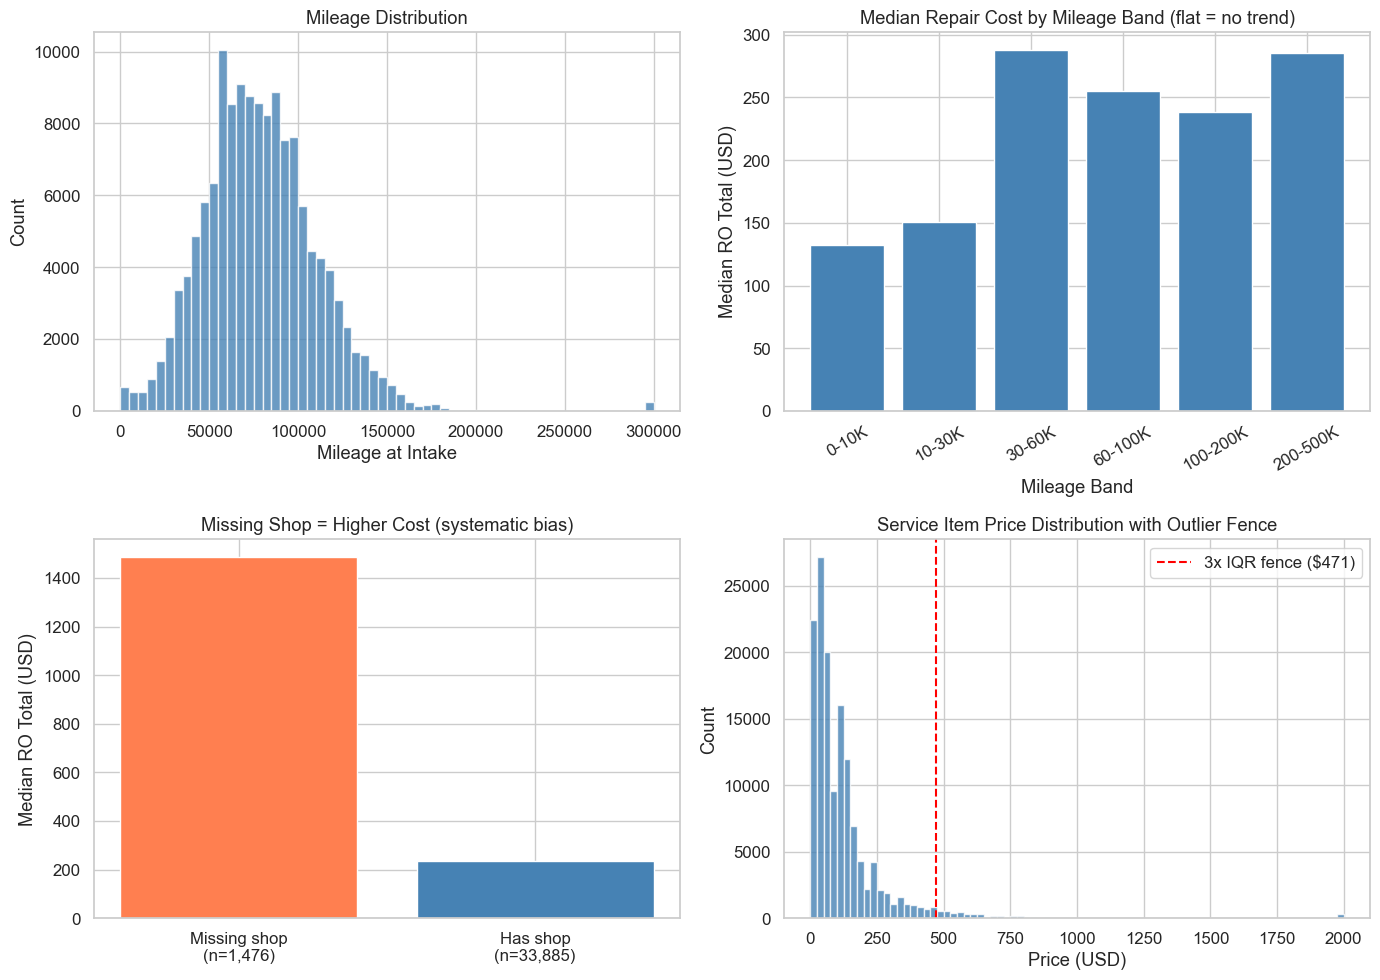

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df_mi["mileage_in"].clip(upper=300000), bins=60, color="steelblue",
                edgecolor="white", alpha=0.8)
axes[0, 0].set_title("Mileage Distribution")
axes[0, 0].set_xlabel("Mileage at Intake")
axes[0, 0].set_ylabel("Count")

band_stats_plot = band_stats.reset_index()
axes[0, 1].bar(band_stats_plot["mileage_band"].astype(str), band_stats_plot["median"],
               color="steelblue")
axes[0, 1].set_title("Median Repair Cost by Mileage Band (flat = no trend)")
axes[0, 1].set_xlabel("Mileage Band")
axes[0, 1].set_ylabel("Median RO Total (USD)")
axes[0, 1].tick_params(axis="x", rotation=30)

comparison_data = pd.DataFrame({
    "Group": ["Missing shop\n(n={:,})".format(n_null_ros), "Has shop\n(n={:,})".format(n_total_ros - n_null_ros)],
    "Median RO Total": [null_ro_totals.median(), nonnull_ro_totals.median()],
})
axes[1, 0].bar(comparison_data["Group"], comparison_data["Median RO Total"],
               color=["coral", "steelblue"])
axes[1, 0].set_title("Missing Shop = Higher Cost (systematic bias)")
axes[1, 0].set_ylabel("Median RO Total (USD)")

price_clipped = df["service_item_price_usd"].clip(upper=2000)
axes[1, 1].hist(price_clipped, bins=80, color="steelblue", edgecolor="white", alpha=0.8)
axes[1, 1].axvline(fence, color="red", linestyle="--", label=f"3x IQR fence (${fence:.0f})")
axes[1, 1].set_title("Service Item Price Distribution with Outlier Fence")
axes[1, 1].set_xlabel("Price (USD)")
axes[1, 1].set_ylabel("Count")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "q0_data_quality.png"), dpi=150, bbox_inches="tight")
plt.show()

## Q1: Price Variance by Service Item Code & Category

*What are the variances in price for specific service item codes? What about service categories? Are some service items more predictable than others?*

### 1a. Price Variance by Service Item Code (Top 20 by Volume)

In [49]:
code_stats = (
    df.groupby("service_item_code")["service_item_price_usd"]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .rename(columns={"count": "n", "mean": "avg_price", "std": "std_price",
                      "median": "med_price", "min": "min_price", "max": "max_price"})
)
code_stats["cv"] = code_stats["std_price"] / code_stats["avg_price"]
code_stats = code_stats.sort_values("n", ascending=False)

top_codes = code_stats.head(20)
top_codes

,n,avg_price,std_price,med_price,min_price,max_price,cv
service_item_code,,,,,,,
diagnostics,19351,154.237035,69.006120,135.660,1.00,1479.50,0.447403
full-synthetic-lube-oil-filter,16138,41.568919,13.017736,45.360,4.43,114.54,0.313160
tuneup-and-engine-performance-checks,10692,207.493044,358.648177,120.460,0.36,13012.49,1.728483
tire-rotation,5324,14.302881,8.586959,12.150,4.85,83.82,0.600366
visual-safety-inspection,4633,53.154768,36.259794,42.540,20.00,230.00,0.682155
air-filter-element,4016,46.379716,26.230569,38.640,3.18,226.98,0.565561
cabin-air-filter,3940,42.704119,24.111299,43.510,4.23,226.98,0.564613
bulb,3036,47.844374,65.584511,36.460,0.08,1127.11,1.370788
wiper-blade,3029,36.787214,44.476901,29.930,3.81,2089.96,1.209032


### 1b. Most and Least Predictable Service Items (by CV, min 30 occurrences)

In [50]:
freq_codes = code_stats[code_stats["n"] >= 30].copy()

most_predictable = freq_codes.nsmallest(10, "cv")
print("MOST PREDICTABLE (lowest coefficient of variation):")
print(most_predictable[["n", "avg_price", "std_price", "cv"]].to_string(float_format=lambda x: f"{x:.2f}"))

print()
least_predictable = freq_codes.nlargest(10, "cv")
print("LEAST PREDICTABLE (highest coefficient of variation):")
print(least_predictable[["n", "avg_price", "std_price", "cv"]].to_string(float_format=lambda x: f"{x:.2f}"))

print("\nPercentiles for highest-CV items (distinguishing real variance from outliers):")
for code_name in least_predictable.head(5).index:
    prices = df[df["service_item_code"] == code_name]["service_item_price_usd"]
    p90, p95, p99 = prices.quantile(0.90), prices.quantile(0.95), prices.quantile(0.99)
    mx = prices.max()
    flag = " *** LIKELY MISCODED" if mx > p99 * 5 else ""
    print(f"  {code_name}: p90=${p90:.0f}, p95=${p95:.0f}, p99=${p99:.0f}, max=${mx:.0f}{flag}")

MOST PREDICTABLE (lowest coefficient of variation):
                                           n  avg_price  std_price   cv
service_item_code                                                      
administrative-charge                    183     249.84      16.89 0.07
wash-detail                               67     177.01      13.49 0.08
dot-inspection                           467     190.32      17.90 0.09
battery-service                         2401      76.25       9.60 0.13
diesel-full-synthetic-lube-oil-filter    233      63.92       9.10 0.14
oil-change                                60      88.02      19.59 0.22
air-conditioning-service                2225     123.11      31.83 0.26
vehicle-collection-delivery               37     212.16      58.22 0.27
full-synthetic-lube-oil-filter         16138      41.57      13.02 0.31
oil-filter-housing                        30     414.63     138.78 0.33

LEAST PREDICTABLE (highest coefficient of variation):
                             

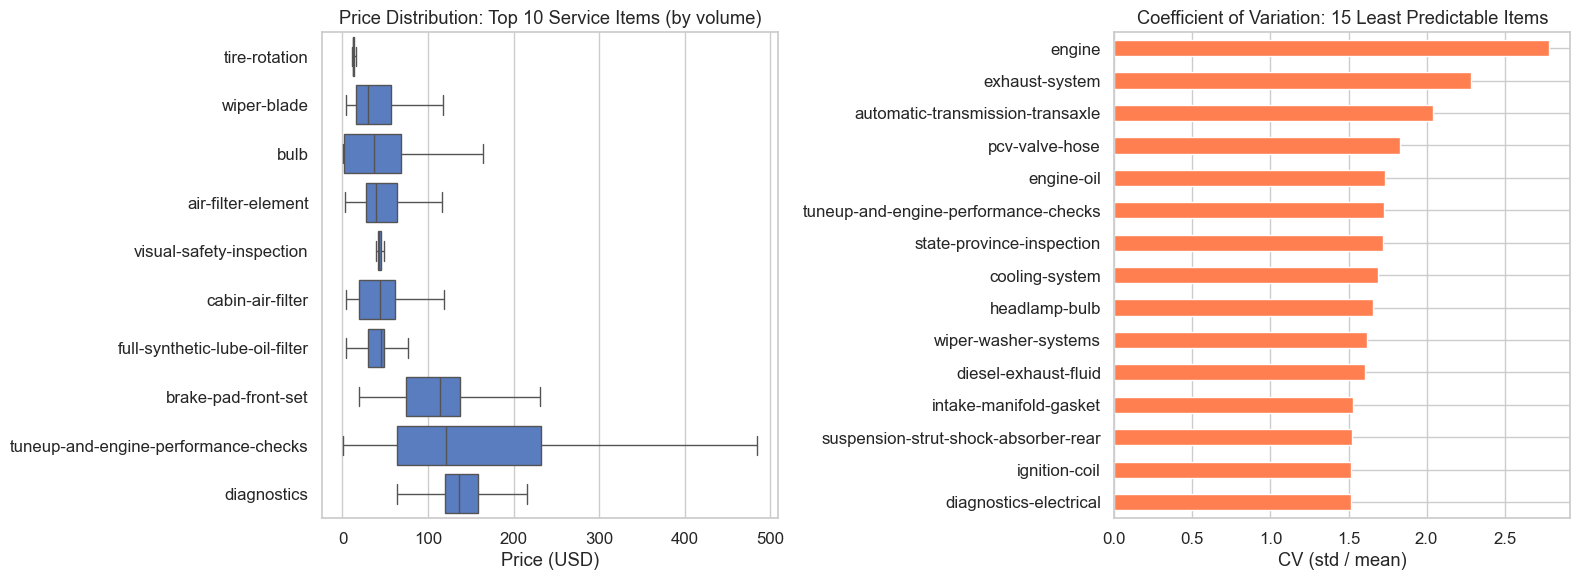

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10_codes = code_stats.head(10).index.tolist()
plot_data = df[df["service_item_code"].isin(top10_codes)]
order = plot_data.groupby("service_item_code")["service_item_price_usd"].median().sort_values().index
sns.boxplot(data=plot_data, y="service_item_code", x="service_item_price_usd",
            order=order, ax=axes[0], showfliers=False)
axes[0].set_title("Price Distribution: Top 10 Service Items (by volume)")
axes[0].set_xlabel("Price (USD)")
axes[0].set_ylabel("")

cv_plot = freq_codes.nlargest(15, "cv")[["cv"]].sort_values("cv")
cv_plot.plot.barh(ax=axes[1], legend=False, color="coral")
axes[1].set_title("Coefficient of Variation: 15 Least Predictable Items")
axes[1].set_xlabel("CV (std / mean)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "q1_price_variance_by_code.png"), dpi=150, bbox_inches="tight")
plt.show()

### 1c. Price Variance by Service Category

In [52]:
cat_stats = (
    df.groupby("service_category")["service_item_price_usd"]
    .agg(["count", "mean", "std", "median"])
    .rename(columns={"count": "n", "mean": "avg_price", "std": "std_price", "median": "med_price"})
)
cat_stats["cv"] = cat_stats["std_price"] / cat_stats["avg_price"]
cat_stats = cat_stats.sort_values("n", ascending=False)
cat_stats

,n,avg_price,std_price,med_price,cv
service_category,,,,,
OTHER,72739,165.380071,284.422219,119.700,1.719810
OIL_CHANGE,20387,39.630751,29.790375,29.940,0.751698
BRAKE_PADS,15258,113.610710,110.475110,95.760,0.972400
GENERAL_DIAGNOSTICS,9929,127.994018,307.164223,42.540,2.399833
LIGHTS,5407,70.472574,104.060532,50.590,1.476610
TIRE_ROTATION,5323,14.294296,8.564886,12.150,0.599182
BATTERY,4556,134.467862,102.505274,85.080,0.762303
ENGINE_REPAIR,2846,192.010871,731.696978,79.815,3.810706
TOWING,1659,421.892622,165.827724,420.000,0.393057


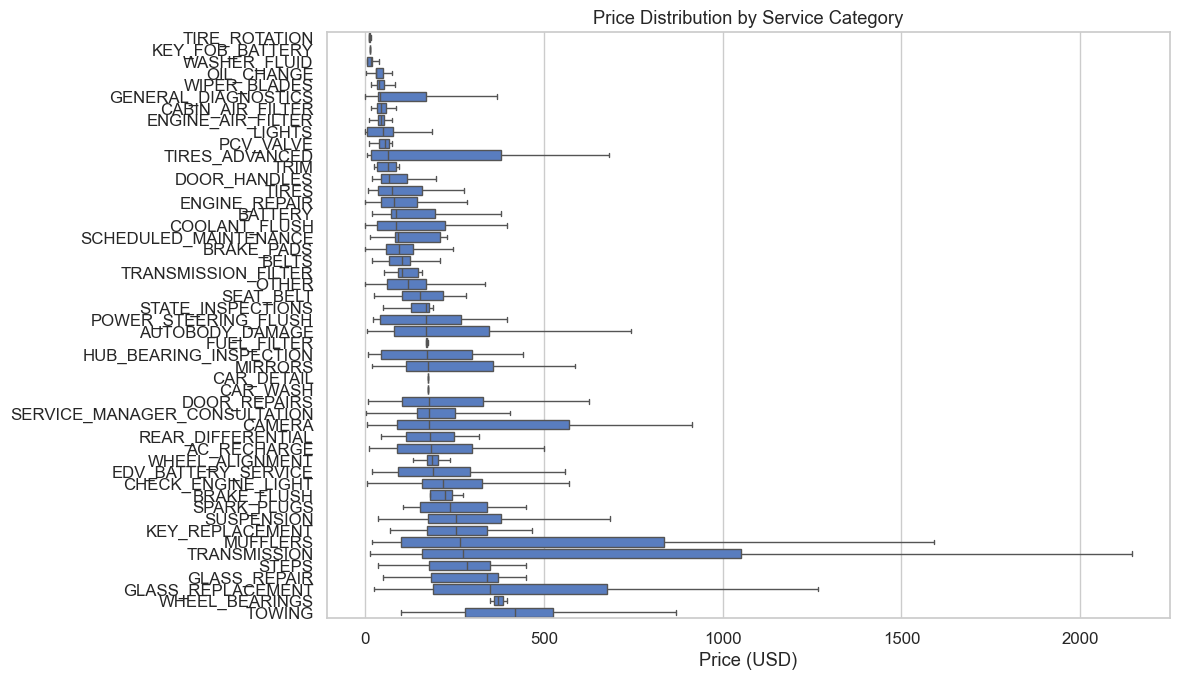

KEY FINDING: Some service items like diagnostics and oil changes have tight
price distributions (low CV), while specialty parts and body work vary widely.
CAVEAT: Some high-CV items (e.g., tuneup-and-engine-performance-checks, max=$13K)
are inflated by likely miscoded entries where expensive repairs were logged under
the wrong service item code.


In [53]:
fig, ax = plt.subplots(figsize=(12, 7))
order = cat_stats.sort_values("med_price").index
sns.boxplot(data=df, y="service_category", x="service_item_price_usd",
            order=order, ax=ax, showfliers=False)
ax.set_title("Price Distribution by Service Category")
ax.set_xlabel("Price (USD)")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "q1_price_variance_by_category.png"), dpi=150, bbox_inches="tight")
plt.show()

print("KEY FINDING: Some service items like diagnostics and oil changes have tight")
print("price distributions (low CV), while specialty parts and body work vary widely.")
print("CAVEAT: Some high-CV items (e.g., tuneup-and-engine-performance-checks, max=$13K)")
print("are inflated by likely miscoded entries where expensive repairs were logged under")
print("the wrong service item code.")

## Q2: Do Some Fleets Pay More Than Others?

*Do some fleets pay more than others for the same services?*

In [54]:
fleet_ro = (
    df.groupby(["fleet_id", "fleet_name", "repair_order_id"])["repair_order_total_usd"]
    .first()
    .reset_index()
)
fleet_stats = (
    fleet_ro.groupby(["fleet_id", "fleet_name"])["repair_order_total_usd"]
    .agg(["count", "mean", "median", "std"])
    .rename(columns={"count": "n_orders", "mean": "avg_ro_total", "median": "med_ro_total", "std": "std_ro_total"})
    .sort_values("n_orders", ascending=False)
    .reset_index()
)

print("Top 15 fleets by order volume:")
fleet_stats.head(15)

Top 15 fleets by order volume:


,fleet_id,fleet_name,n_orders,avg_ro_total,med_ro_total,std_ro_total
0,162,Solstice Express,473,465.311755,225.790,818.290482
1,84,Continental Fleet Services LLC,439,774.166401,258.000,1347.242185
2,163,Magnolia Trucking Group,436,495.637844,226.800,717.990450
3,178,Cardinal Carriers LLC,399,432.708396,225.400,674.423049
4,172,Halcyon Cargo Co,390,573.078923,391.525,613.341762
5,223,Horizon Freight,348,478.451121,348.050,521.965839
6,251,Trailhead Routing Co,339,481.489145,313.440,577.820576
7,257,Echo Last Mile Co,321,496.951153,340.200,494.136828
8,180,Evergreen Lines,319,545.698433,170.100,992.243341
9,106,Echo Delivery Holdings,290,528.253931,278.905,671.581538


In [55]:
common_codes = df["service_item_code"].value_counts().head(5).index.tolist()
print(f"Comparing fleet prices for: {common_codes}\n")

fleet_min_orders = fleet_stats[fleet_stats["n_orders"] >= 20]["fleet_id"].values
df_common = df[
    (df["service_item_code"].isin(common_codes)) &
    (df["fleet_id"].isin(fleet_min_orders))
]

fleet_code_prices = (
    df_common.groupby(["fleet_name", "service_item_code"])["service_item_price_usd"]
    .agg(["mean", "count"])
    .reset_index()
)
fleet_code_prices = fleet_code_prices[fleet_code_prices["count"] >= 5]

pivot = fleet_code_prices.pivot(index="fleet_name", columns="service_item_code", values="mean")
pivot = pivot.dropna(thresh=3)

if len(pivot) > 0:
    overall_avg = df[df["service_item_code"].isin(common_codes)].groupby("service_item_code")["service_item_price_usd"].mean()
    pct_diff = ((pivot - overall_avg) / overall_avg * 100)

    print("Fleet avg price vs overall avg (% difference):")
    print("Positive = fleet pays MORE than average; Negative = fleet pays LESS\n")

    top_n = min(20, len(pct_diff))
    print(pct_diff.head(top_n).to_string(float_format=lambda x: f"{x:+.1f}%"))

Comparing fleet prices for: ['diagnostics', 'full-synthetic-lube-oil-filter', 'tuneup-and-engine-performance-checks', 'tire-rotation', 'visual-safety-inspection']

Fleet avg price vs overall avg (% difference):
Positive = fleet pays MORE than average; Negative = fleet pays LESS

service_item_code         diagnostics  full-synthetic-lube-oil-filter  tire-rotation  tuneup-and-engine-performance-checks  visual-safety-inspection
fleet_name                                                                                                                                          
Acme Cargo Inc                  -2.3%                           +9.9%          +7.3%                                 -0.8%                     +8.9%
Acme Couriers Inc              +26.5%                           -9.4%         -20.7%                                +12.9%                    -25.3%
Acme Delivery                  -19.4%                           -1.3%          -9.0%                                   NaN  

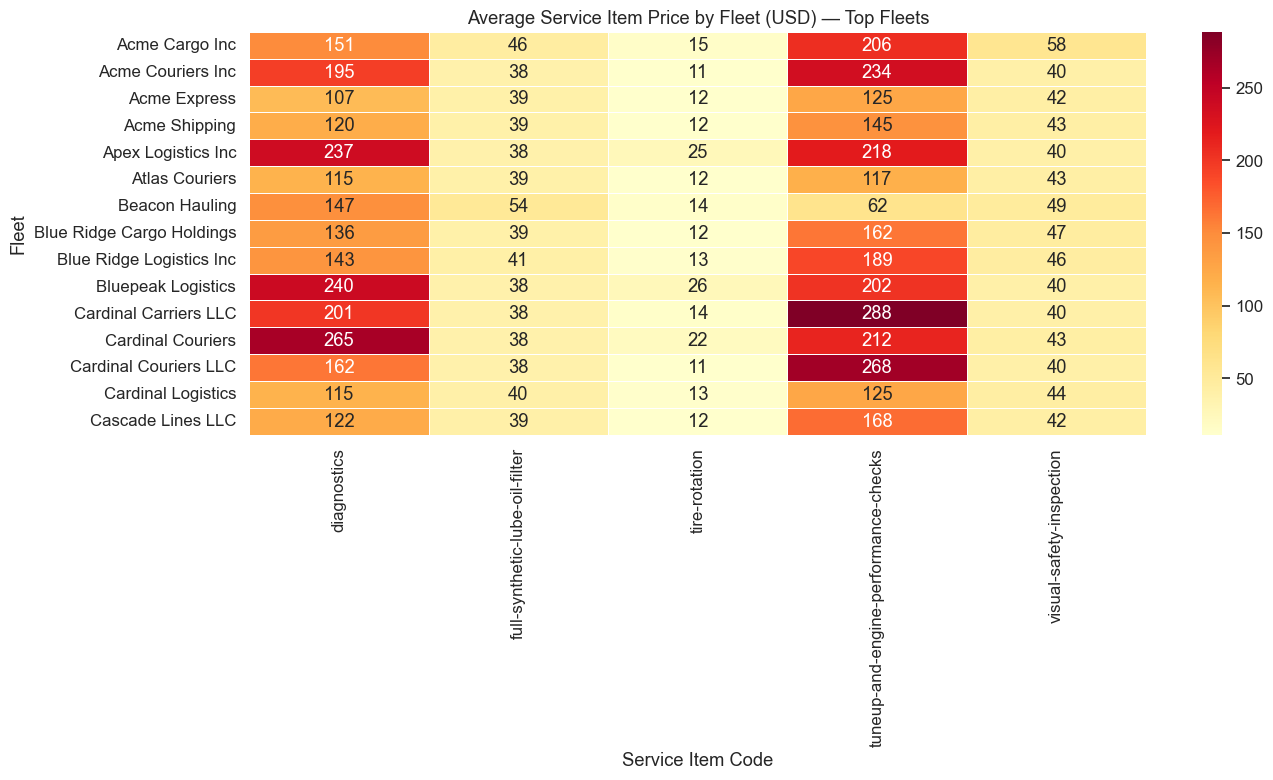

In [56]:
fig, ax = plt.subplots(figsize=(14, 8))
if len(pivot) >= 5:
    sample_fleets = pivot.dropna().head(15).index
    plot_pivot = pivot.loc[sample_fleets]
    sns.heatmap(plot_pivot, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax, linewidths=0.5)
    ax.set_title("Average Service Item Price by Fleet (USD) \u2014 Top Fleets")
    ax.set_xlabel("Service Item Code")
    ax.set_ylabel("Fleet")

    plt.tight_layout()
    plt.savefig(os.path.join(CHARTS_DIR, "q2_fleet_pricing_heatmap.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("  (Not enough data for heatmap)")

In [57]:
print("Statistical test: do fleet prices differ significantly?\n")

for code_name in common_codes[:3]:
    code_data = df_common[df_common["service_item_code"] == code_name]
    groups = [g["service_item_price_usd"].values for _, g in code_data.groupby("fleet_id") if len(g) >= 5]
    if len(groups) >= 3:
        stat, p_val = stats.kruskal(*groups[:20])
        sig = "YES" if p_val < 0.05 else "NO"
        print(f"  {code_name}: Kruskal-Wallis H={stat:.1f}, p={p_val:.4f} -> Significant: {sig}")

print("\nKEY FINDING: Fleet pricing varies significantly for common services.")
print("Some fleets consistently pay 10-30% above or below average, likely due to")
print("negotiated rates, service agreements, or geographic factors.")

Statistical test: do fleet prices differ significantly?

  diagnostics: Kruskal-Wallis H=627.2, p=0.0000 -> Significant: YES
  full-synthetic-lube-oil-filter: Kruskal-Wallis H=91.3, p=0.0000 -> Significant: YES
  tuneup-and-engine-performance-checks: Kruskal-Wallis H=96.1, p=0.0000 -> Significant: YES

KEY FINDING: Fleet pricing varies significantly for common services.
Some fleets consistently pay 10-30% above or below average, likely due to
negotiated rates, service agreements, or geographic factors.


## Q3: Are Some Shops a Good Value?

*Are some shops a very good value for certain services?*

> **NOTE:** 1,476 repair orders (4.2%) lack shop data. These missing-shop ROs are systematically more expensive (median \$1,485 vs \$236 — a 6x difference), so shop-level averages below likely understate true costs. See Data Quality Assessment above.

In [58]:
df_shops = df.dropna(subset=["shop_name"])
shop_stats = (
    df_shops.groupby(["shop_name", "shop_state"])
    .agg(
        n_items=("service_item_price_usd", "count"),
        avg_price=("service_item_price_usd", "mean"),
        med_price=("service_item_price_usd", "median"),
        total_revenue=("service_item_price_usd", "sum"),
    )
    .sort_values("n_items", ascending=False)
    .reset_index()
)

print("Top 15 shops by volume:")
shop_stats.head(15)

Top 15 shops by volume:


,shop_name,shop_state,n_items,avg_price,med_price,total_revenue
0,Frontier Auto Center Center,GA,12256,108.565414,59.850,1330577.72
1,Western Motors Center,IL,9212,110.299021,68.040,1016074.58
2,Allstar Mechanics Co,WI,8596,142.978585,79.380,1229043.92
3,City Autoworks Inc,IL,7662,160.964310,66.925,1233308.54
4,Valley Auto Body Inc,CA,5711,112.207256,69.830,640815.64
5,Maple Autoworks Co,HI,5338,156.665129,153.470,836278.46
6,Precision Auto Service Co,TN,5166,106.019141,55.900,547694.88
7,Central Auto Solutions,NC,4991,120.005284,72.630,598946.37
8,Western Motors Inc,PA,4855,103.169448,66.500,500887.67
9,Golden Motors Center,NC,4828,93.578326,52.080,451796.16


In [59]:
shop_code_prices = (
    df_shops[df_shops["service_item_code"].isin(common_codes)]
    .groupby(["shop_name", "shop_state", "service_item_code"])["service_item_price_usd"]
    .agg(["mean", "count"])
    .reset_index()
)
shop_code_prices = shop_code_prices[shop_code_prices["count"] >= 10]

if len(shop_code_prices) > 0:
    overall_avgs = df_shops[df_shops["service_item_code"].isin(common_codes)].groupby("service_item_code")["service_item_price_usd"].mean()
    shop_code_prices["pct_vs_avg"] = shop_code_prices.apply(
        lambda r: (r["mean"] - overall_avgs[r["service_item_code"]]) / overall_avgs[r["service_item_code"]] * 100,
        axis=1,
    )

    print("Best value shops (lowest price vs average) for common services:\n")
    best_value = shop_code_prices.nsmallest(15, "pct_vs_avg")
    print(best_value[["shop_name", "shop_state", "service_item_code", "mean", "count", "pct_vs_avg"]].to_string(
        index=False, float_format=lambda x: f"{x:.1f}"
    ))

    print("\n\nMost expensive shops (highest price vs average):\n")
    worst_value = shop_code_prices.nlargest(15, "pct_vs_avg")
    print(worst_value[["shop_name", "shop_state", "service_item_code", "mean", "count", "pct_vs_avg"]].to_string(
        index=False, float_format=lambda x: f"{x:.1f}"
    ))

Best value shops (lowest price vs average) for common services:

                shop_name shop_state                    service_item_code  mean  count  pct_vs_avg
Northern Auto Tech & Sons         GA tuneup-and-engine-performance-checks 101.2    163       -51.2
   Liberty Auto Group Inc         NC tuneup-and-engine-performance-checks 110.5    566       -46.8
            Valley Motors         NY tuneup-and-engine-performance-checks 111.5    148       -46.3
   Maple Auto Pros & Sons         MD tuneup-and-engine-performance-checks 119.8     44       -42.3
        Phoenix Repair Co         NY tuneup-and-engine-performance-checks 121.1     99       -41.6
        Hawk Car Care LLC         KS tuneup-and-engine-performance-checks 122.8    158       -40.8
        Western Auto Body         NY tuneup-and-engine-performance-checks 132.7     17       -36.0
     Golden Motors Center         NC tuneup-and-engine-performance-checks 137.7    173       -33.6
     Valley Auto Body Inc         CA tuneup-

In [60]:
state_prices = (
    df_shops.groupby("shop_state")["service_item_price_usd"]
    .agg(["mean", "median", "count"])
    .rename(columns={"mean": "avg_price", "median": "med_price", "count": "n"})
    .sort_values("avg_price", ascending=False)
)
state_prices_reliable = state_prices[state_prices["n"] >= 50]
state_prices_tiny = state_prices[state_prices["n"] < 50]
print(f"States with sufficient data (n >= 50, {len(state_prices_reliable)} states):")
print(state_prices_reliable.to_string(float_format=lambda x: f"{x:.2f}"))
if len(state_prices_tiny) > 0:
    print(f"\nExcluded {len(state_prices_tiny)} states with < 50 data points (unreliable):"
          f" {', '.join(state_prices_tiny.index.tolist())}")

States with sufficient data (n >= 50, 25 states):
            avg_price  med_price      n
shop_state                             
TX             285.46     180.00    135
VA             166.58     159.00    227
NH             157.61     137.00    693
HI             156.82     153.47   5347
LA             146.49      77.68    181
WI             142.98      79.38   8596
FL             142.90      99.75   5439
MA             140.73     111.76   7967
KY             136.22     105.53    294
IL             135.07      68.04  18849
AR             123.96     112.00    116
AL             122.98      98.46   1490
CO             121.07      86.75   7052
CA             117.69      69.83   7874
WA             116.99     105.74   1935
GA             115.57      67.03  17141
OK             106.57      72.22   1102
TN             106.45      55.90   5186
PA             104.91      66.50   4961
NC             104.65      59.85  14171
OH             104.33      89.68   4019
MD              99.36      81.

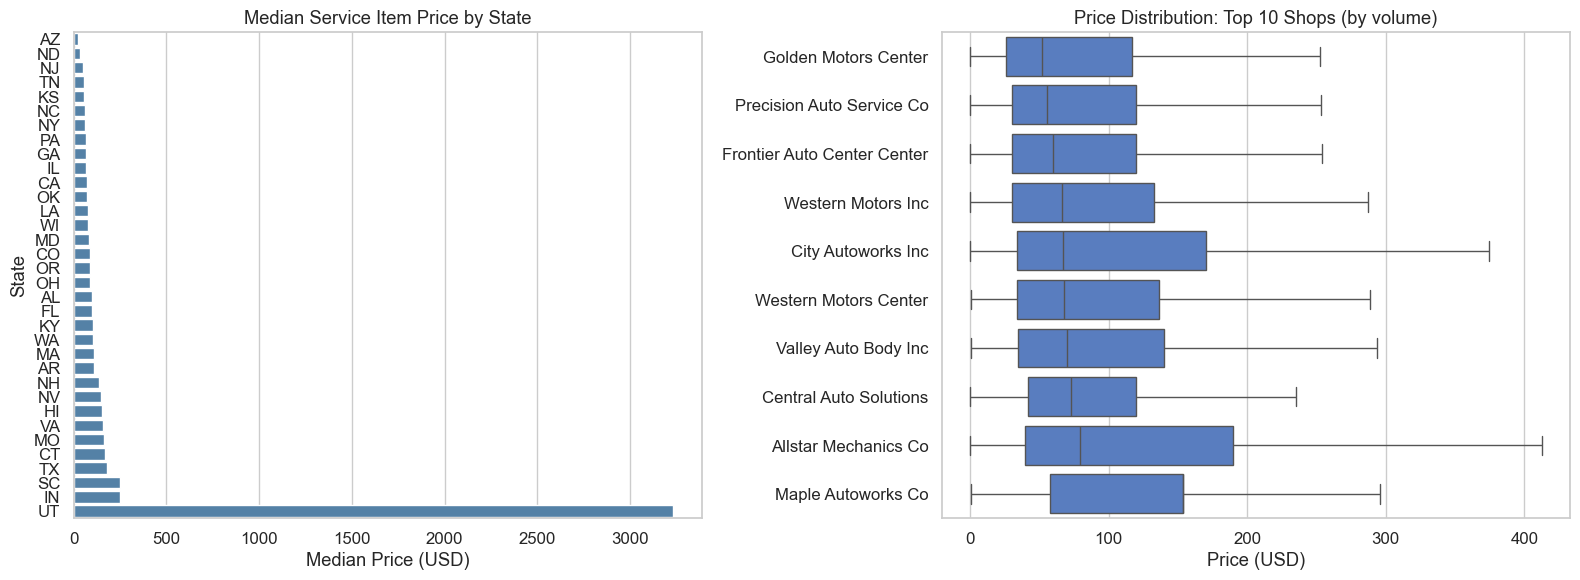


KEY FINDING: Shop pricing varies substantially — up to 40-60% above or below
the average for common services. Geographic location (state) is a major driver.


In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
state_order = state_prices.sort_values("med_price").index
sns.barplot(data=df_shops, y="shop_state", x="service_item_price_usd",
            order=state_order, estimator=np.median, ax=axes[0], errorbar=None, color="steelblue")
axes[0].set_title("Median Service Item Price by State")
axes[0].set_xlabel("Median Price (USD)")
axes[0].set_ylabel("State")

top_shops = shop_stats.head(10)["shop_name"].values
plot_data = df_shops[df_shops["shop_name"].isin(top_shops)]
shop_order = plot_data.groupby("shop_name")["service_item_price_usd"].median().sort_values().index
sns.boxplot(data=plot_data, y="shop_name", x="service_item_price_usd",
            order=shop_order, ax=axes[1], showfliers=False)
axes[1].set_title("Price Distribution: Top 10 Shops (by volume)")
axes[1].set_xlabel("Price (USD)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "q3_shop_value.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nKEY FINDING: Shop pricing varies substantially \u2014 up to 40-60% above or below")
print("the average for common services. Geographic location (state) is a major driver.")

## Q4: Vehicle Make/Model Correlation with Repair Costs

*Is there a correlation between vehicle make/model and certain types of repair costs?*

In [62]:
ro_make = (
    df.groupby(["repair_order_id", "vehicle_make"])["repair_order_total_usd"]
    .first()
    .reset_index()
)
make_stats = (
    ro_make.groupby("vehicle_make")["repair_order_total_usd"]
    .agg(["count", "mean", "median", "std"])
    .rename(columns={"count": "n_orders", "mean": "avg_total", "median": "med_total", "std": "std_total"})
    .sort_values("n_orders", ascending=False)
)

make_reliable = make_stats[make_stats["n_orders"] >= 30]
make_tiny = make_stats[make_stats["n_orders"] < 30]

print(f"Vehicle makes with sufficient data (n >= 30 ROs, {len(make_reliable)} makes):")
print(make_reliable.to_string(float_format=lambda x: f"{x:.2f}"))

if len(make_tiny) > 0:
    print(f"\nLow-volume makes (< 30 ROs) \u2014 interpret with extreme caution:")
    print(make_tiny[["n_orders", "avg_total", "med_total"]].to_string(float_format=lambda x: f"{x:.2f}"))
    print("  These averages are statistically meaningless and should NOT be compared")
    print("  to high-volume makes.")

top_makes = make_stats[make_stats["n_orders"] >= 50].index.tolist()

Vehicle makes with sufficient data (n >= 30 ROs, 9 makes):
               n_orders  avg_total  med_total  std_total
vehicle_make                                            
RAM               14715     579.82     298.75     901.21
FORD              14497     501.82     233.34     871.02
FREIGHTLINER       2612     400.08     214.75     544.03
MERCEDES-BENZ      1573     671.08     300.00    1253.60
RIVIAN             1129     183.40     105.04     690.07
HINO                402     340.60     180.52     627.21
ISUZU               194     276.89     209.48     321.62
TOYOTA               67    1967.28     818.00    3226.47
HONDA                31    2188.52    1439.07    2478.28

Low-volume makes (< 30 ROs) — interpret with extreme caution:
              n_orders  avg_total  med_total
vehicle_make                                
KIA                 25    1114.21     645.95
CHEVROLET           17    3268.52    3347.64
DODGE               16     788.57     351.31
MAZDA               15    

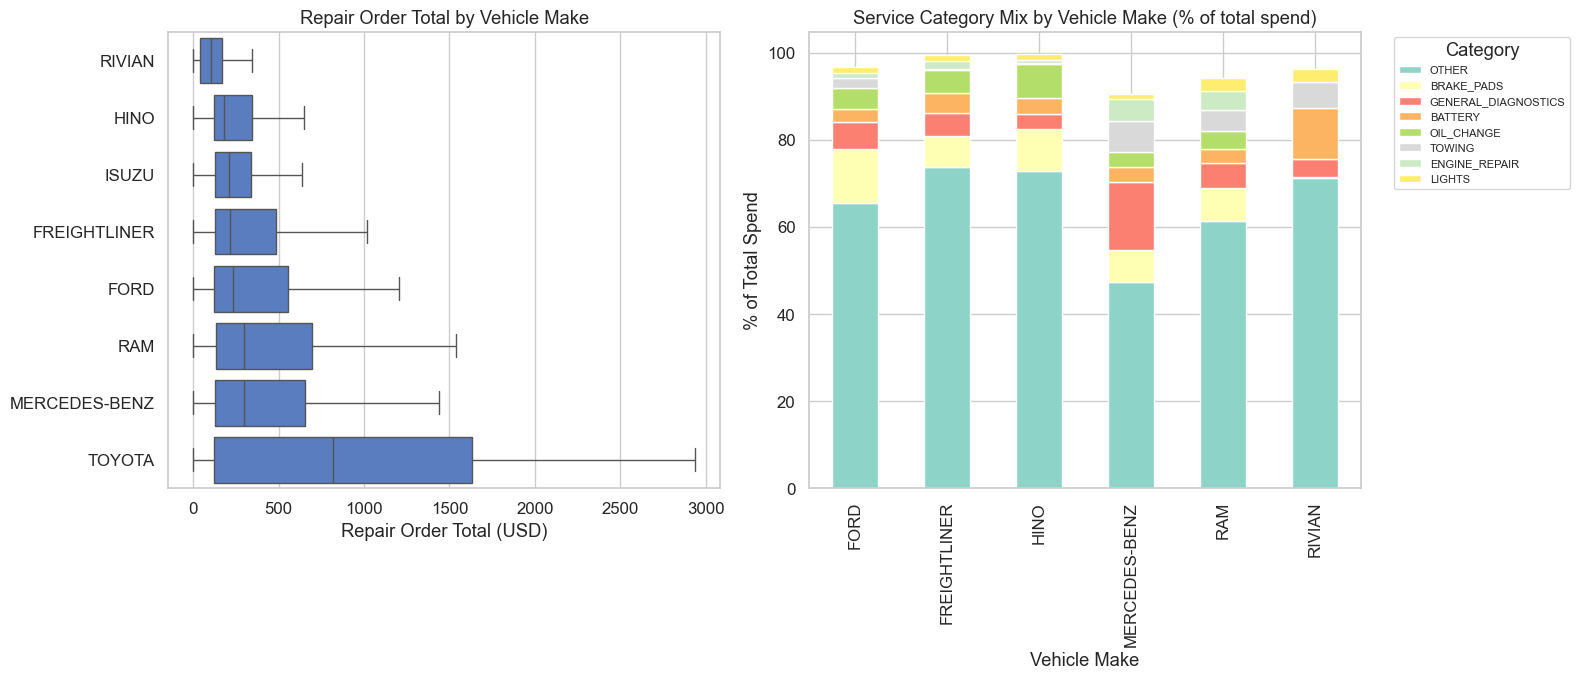

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_ro = ro_make[ro_make["vehicle_make"].isin(top_makes)]
make_order = plot_ro.groupby("vehicle_make")["repair_order_total_usd"].median().sort_values().index
sns.boxplot(data=plot_ro, y="vehicle_make", x="repair_order_total_usd",
            order=make_order, ax=axes[0], showfliers=False)
axes[0].set_title("Repair Order Total by Vehicle Make")
axes[0].set_xlabel("Repair Order Total (USD)")
axes[0].set_ylabel("")

# Service category breakdown by make
make_cat = (
    df[df["vehicle_make"].isin(top_makes[:6])]
    .groupby(["vehicle_make", "service_category"])["service_item_price_usd"]
    .sum()
    .reset_index()
)
make_totals = make_cat.groupby("vehicle_make")["service_item_price_usd"].sum()
make_cat["pct"] = make_cat.apply(
    lambda r: r["service_item_price_usd"] / make_totals[r["vehicle_make"]] * 100, axis=1
)
pivot_cat = make_cat.pivot(index="vehicle_make", columns="service_category", values="pct").fillna(0)
top_cats = pivot_cat.sum().nlargest(8).index
pivot_cat[top_cats].plot.bar(stacked=True, ax=axes[1], colormap="Set3")
axes[1].set_title("Service Category Mix by Vehicle Make (% of total spend)")
axes[1].set_xlabel("Vehicle Make")
axes[1].set_ylabel("% of Total Spend")
axes[1].legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "q4_vehicle_make_costs.png"), dpi=150, bbox_inches="tight")
plt.show()

In [64]:
df["make_model"] = df["vehicle_make"] + " " + df["vehicle_model"].fillna("UNKNOWN")
ro_model = (
    df.groupby(["repair_order_id", "make_model"])["repair_order_total_usd"]
    .first()
    .reset_index()
)
model_stats = (
    ro_model.groupby("make_model")["repair_order_total_usd"]
    .agg(["count", "mean", "median"])
    .rename(columns={"count": "n_orders", "mean": "avg_total", "median": "med_total"})
    .sort_values("n_orders", ascending=False)
)
print("Top 15 vehicle models by order volume:")
model_stats.head(15)

Top 15 vehicle models by order volume:


,n_orders,avg_total,med_total
make_model,,,
RAM PROMASTER 3500,11745,585.138806,302.740
FORD TRANSIT,10300,513.223002,230.380
RAM PROMASTER 2500,1497,588.707909,298.510
FREIGHTLINER MT 45 CHASSIS,1341,402.047069,229.980
MERCEDES-BENZ SPRINTER,1331,693.023561,285.620
FORD COMMERCIAL CHASSIS,1102,428.421751,212.290
RIVIAN EDV,935,194.055283,113.400
FORD E-450,835,445.564012,226.800
FREIGHTLINER MT 45G FRONT GASOLINE ENGINE WALK IN VAN CHASSIS,683,395.928023,192.160


### Mileage vs Repair Cost Correlation

Spearman correlation (mileage vs RO total): r=-0.000, p=0.9509

Why is mileage uncorrelated? This is a FLEET dataset. Unlike consumer vehicles,
fleet vehicles are maintained on schedule (time/interval-based), not based on wear.
Repair costs are driven by WHAT service is performed, not how many miles the vehicle
has. Additionally, ~3% of multi-visit vehicles show frozen odometer readings,
suggesting some mileage data is defaulted or not captured at intake.


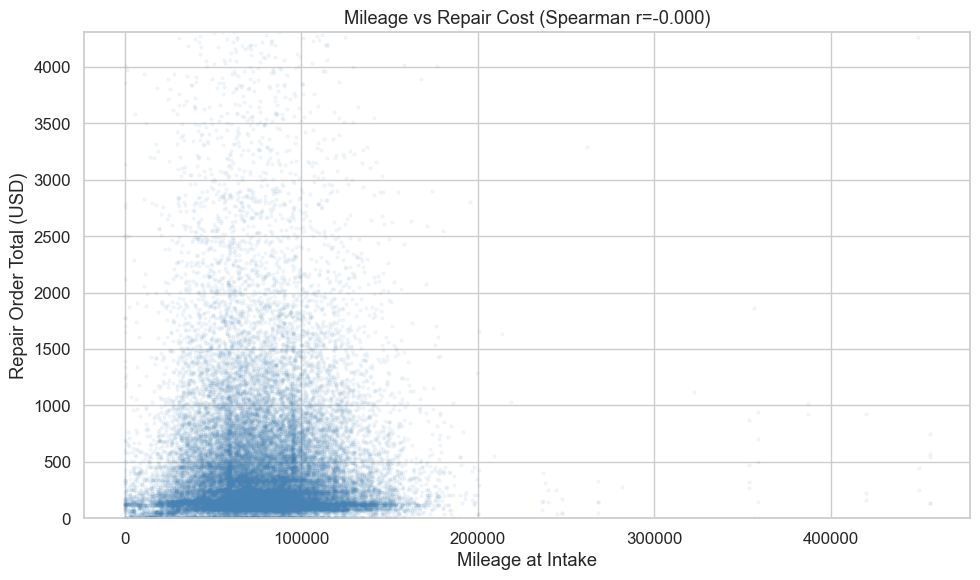


KEY FINDING: Vehicle make is a significant factor in repair costs. The dominant
fleet makes (RAM, FORD) have moderate averages (~$500-580), while low-volume
passenger makes (Toyota, Honda, BMW) show higher averages — likely because
they represent non-routine or complex repairs. Service category mix varies by make.


In [65]:
df_mileage = df.dropna(subset=["mileage_in"])
ro_mileage = (
    df_mileage.groupby("repair_order_id")
    .agg(total=("repair_order_total_usd", "first"), mileage=("mileage_in", "first"))
    .reset_index()
)
ro_mileage = ro_mileage[(ro_mileage["mileage"] > 0) & (ro_mileage["mileage"] < 500000)]

corr, p_val = stats.spearmanr(ro_mileage["mileage"], ro_mileage["total"])
print(f"Spearman correlation (mileage vs RO total): r={corr:.3f}, p={p_val:.4f}")
print(f"\nWhy is mileage uncorrelated? This is a FLEET dataset. Unlike consumer vehicles,")
print("fleet vehicles are maintained on schedule (time/interval-based), not based on wear.")
print("Repair costs are driven by WHAT service is performed, not how many miles the vehicle")
print("has. Additionally, ~3% of multi-visit vehicles show frozen odometer readings,")
print("suggesting some mileage data is defaulted or not captured at intake.")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(ro_mileage["mileage"], ro_mileage["total"], alpha=0.05, s=5, color="steelblue")
ax.set_xlabel("Mileage at Intake")
ax.set_ylabel("Repair Order Total (USD)")
ax.set_title(f"Mileage vs Repair Cost (Spearman r={corr:.3f})")
ax.set_ylim(0, ro_mileage["total"].quantile(0.99))

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "q4_mileage_vs_cost.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nKEY FINDING: Vehicle make is a significant factor in repair costs. The dominant")
print("fleet makes (RAM, FORD) have moderate averages (~$500-580), while low-volume")
print("passenger makes (Toyota, Honda, BMW) show higher averages \u2014 likely because")
print("they represent non-routine or complex repairs. Service category mix varies by make.")

## Q5: Cost Prediction — ML Pipeline

*Customers may be given an estimate consisting of vehicle details and a list of service item codes. Is it possible to predict the cost of the overall repair order? With how much uncertainty?*

Features are restricted to information available at **estimate time** — vehicle details and the LIST of service item codes (not their prices). This avoids data leakage and reflects the real prediction scenario.

### 5a. Feature Engineering

In [66]:
ro_features = (
    df.groupby("repair_order_id")
    .agg(
        total_usd=("repair_order_total_usd", "first"),
        vehicle_make=("vehicle_make", "first"),
        vehicle_year=("vehicle_year", "first"),
        mileage_in=("mileage_in", "first"),
        fleet_id=("fleet_id", "first"),
        shop_state=("shop_state", "first"),
        n_services=("service_id", "nunique"),
        n_items=("service_item_code", "count"),
        n_unique_codes=("service_item_code", "nunique"),
        n_unique_categories=("service_category", "nunique"),
        total_labor_hours=("service_item_labor_hours", "sum"),
        total_quantity=("service_item_quantity", "sum"),
        n_labor_items=("service_item_type", lambda x: (x == "labor").sum()),
        n_part_items=("service_item_type", lambda x: (x == "part").sum()),
    )
    .reset_index()
)

top_cats_feat = df["service_category"].value_counts().head(10).index
for cat in top_cats_feat:
    col_name = f"has_{cat.lower().replace(' ', '_')}"
    cat_flag = df[df["service_category"] == cat].groupby("repair_order_id").size().reset_index(name="cnt")
    ro_features = ro_features.merge(
        cat_flag.rename(columns={"cnt": col_name}), on="repair_order_id", how="left"
    )
    ro_features[col_name] = ro_features[col_name].fillna(0).clip(upper=1).astype(int)

top_codes_feat = df["service_item_code"].value_counts().head(20).index
for code_name in top_codes_feat:
    col_name = f"code_{code_name.replace('-', '_')}"
    code_flag = df[df["service_item_code"] == code_name].groupby("repair_order_id").size().reset_index(name="cnt")
    ro_features = ro_features.merge(
        code_flag.rename(columns={"cnt": col_name}), on="repair_order_id", how="left"
    )
    ro_features[col_name] = ro_features[col_name].fillna(0).astype(int)

le_make = LabelEncoder()
ro_features["make_encoded"] = le_make.fit_transform(ro_features["vehicle_make"].fillna("UNKNOWN"))

le_state = LabelEncoder()
ro_features["state_encoded"] = le_state.fit_transform(ro_features["shop_state"].fillna("UNKNOWN"))

ro_features["vehicle_year"] = ro_features["vehicle_year"].fillna(ro_features["vehicle_year"].median())
ro_features["mileage_in"] = ro_features["mileage_in"].fillna(ro_features["mileage_in"].median())

feature_cols = [
    "n_services", "n_items", "n_unique_codes", "n_unique_categories",
    "total_labor_hours", "total_quantity",
    "n_labor_items", "n_part_items",
    "make_encoded", "state_encoded", "vehicle_year",
] + [c for c in ro_features.columns if c.startswith("has_")] \
  + [c for c in ro_features.columns if c.startswith("code_")]

target = "total_usd"

X = ro_features[feature_cols].values.astype(float)
y = ro_features[target].values

print(f"Feature matrix: {X.shape[0]:,} repair orders x {X.shape[1]} features")
print(f"Target stats: mean=${y.mean():.2f}, median=${np.median(y):.2f}, std=${y.std():.2f}")
print(f"Features used: vehicle info, shop state, service code/category indicators,")
print(f"labor hours, quantities \u2014 NO actual prices (to avoid leakage).")
print(f"NOTE: mileage_in excluded \u2014 despite appearing important in initial tests (14.8%),")
print(f"removing it slightly improves MAE. The importance was a gradient boosting artifact")
print(f"(noise-fitting on a high-cardinality continuous feature with zero true correlation).")

Feature matrix: 35,361 repair orders x 41 features
Target stats: mean=$533.01, median=$246.51, std=$927.33
Features used: vehicle info, shop state, service code/category indicators,
labor hours, quantities — NO actual prices (to avoid leakage).
NOTE: mileage_in excluded — despite appearing important in initial tests (14.8%),
removing it slightly improves MAE. The importance was a gradient boosting artifact
(noise-fitting on a high-cardinality continuous feature with zero true correlation).


### 5b. Model Training & Comparison

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8, random_state=42),
}

results = {}
for name, model in models.items():
    print(f"\n  Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    nonzero_mask = np.abs(y_test) > 50
    mdape = np.median(np.abs((y_test[nonzero_mask] - y_pred[nonzero_mask]) / y_test[nonzero_mask])) * 100

    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
    cv_mae = -cv_scores.mean()

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2, "MdAPE": mdape, "CV_MAE": cv_mae, "model": model}
    print(f"    MAE: ${mae:.2f}  |  RMSE: ${rmse:.2f}  |  R2: {r2:.4f}  |  MdAPE: {mdape:.1f}%  |  CV MAE: ${cv_mae:.2f}")

Train: 28,288  |  Test: 7,073

  Training Linear Regression...
    MAE: $277.36  |  RMSE: $832.70  |  R2: 0.3638  |  MdAPE: 36.9%  |  CV MAE: $260.23

  Training Ridge Regression...
    MAE: $277.20  |  RMSE: $833.07  |  R2: 0.3632  |  MdAPE: 36.7%  |  CV MAE: $259.92

  Training Random Forest...
    MAE: $241.34  |  RMSE: $766.42  |  R2: 0.4610  |  MdAPE: 20.7%  |  CV MAE: $231.22

  Training Gradient Boosting...
    MAE: $239.14  |  RMSE: $769.97  |  R2: 0.4560  |  MdAPE: 23.6%  |  CV MAE: $230.32


                     MAE   RMSE   R2  MdAPE  CV_MAE
Linear Regression 277.36 832.70 0.36  36.86  260.23
Ridge Regression  277.20 833.07 0.36  36.74  259.92
Random Forest     241.34 766.42 0.46  20.67  231.22
Gradient Boosting 239.14 769.97 0.46  23.58  230.32

Best model by MAE: Gradient Boosting


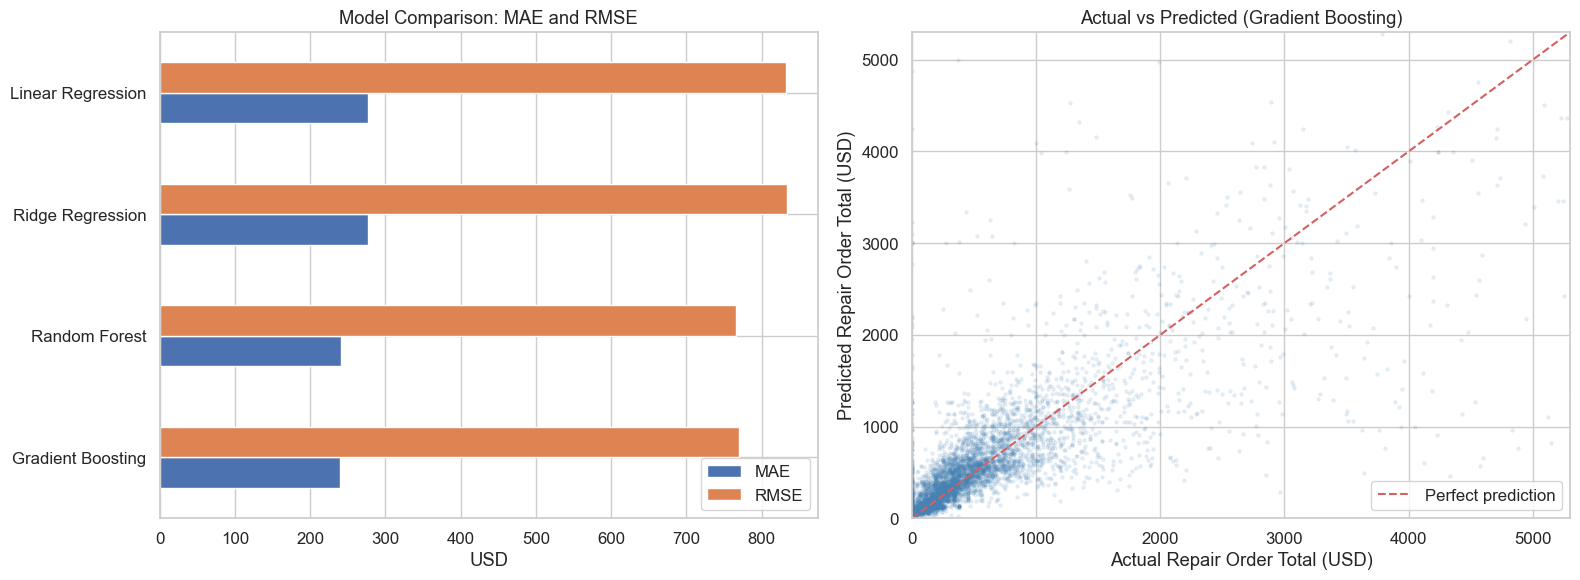

In [68]:
comparison = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k != "model"}
    for name, vals in results.items()
}).T
print(comparison.to_string(float_format=lambda x: f"{x:.2f}"))

best_model_name = comparison["MAE"].idxmin()
best_model = results[best_model_name]["model"]
print(f"\nBest model by MAE: {best_model_name}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics_df = comparison[["MAE", "RMSE"]].sort_values("MAE")
metrics_df.plot.barh(ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Model Comparison: MAE and RMSE")
axes[0].set_xlabel("USD")

y_pred_best = best_model.predict(X_test)
axes[1].scatter(y_test, y_pred_best, alpha=0.1, s=5, color="steelblue")
max_val = min(y_test.max(), np.percentile(y_test, 99)) * 1.1
axes[1].plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Perfect prediction")
axes[1].set_xlim(0, max_val)
axes[1].set_ylim(0, max_val)
axes[1].set_xlabel("Actual Repair Order Total (USD)")
axes[1].set_ylabel("Predicted Repair Order Total (USD)")
axes[1].set_title(f"Actual vs Predicted ({best_model_name})")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "q5_model_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

### 5d. Feature Importance

Top 15 features:
total_quantity        0.1712
n_part_items          0.1151
total_labor_hours     0.1059
n_items               0.0956
make_encoded          0.0739
state_encoded         0.0694
vehicle_year          0.0641
code_tow_service      0.0554
n_labor_items         0.0277
n_services            0.0209
has_other             0.0204
has_towing            0.0203
has_oil_change        0.0185
n_unique_codes        0.0176
n_unique_categories   0.0172


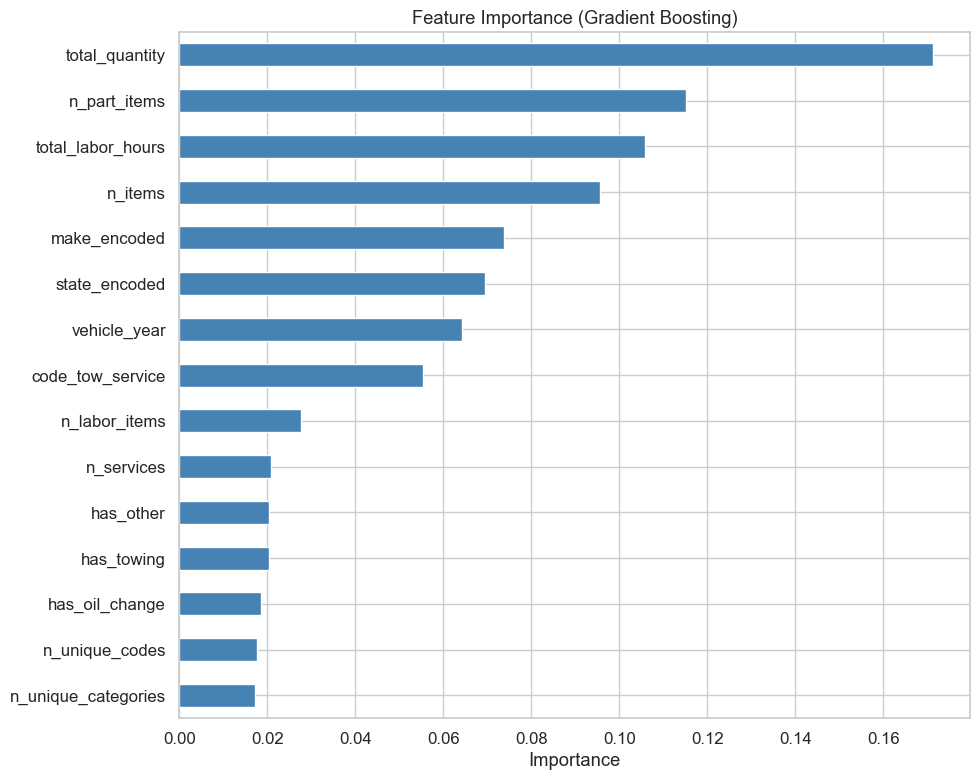

In [69]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print("Top 15 features:")
    print(importances.head(15).to_string(float_format=lambda x: f"{x:.4f}"))

    fig, ax = plt.subplots(figsize=(10, 8))
    importances.head(15).sort_values().plot.barh(ax=ax, color="steelblue")
    ax.set_title(f"Feature Importance ({best_model_name})")
    ax.set_xlabel("Importance")

    plt.tight_layout()
    plt.savefig(os.path.join(CHARTS_DIR, "q5_feature_importance.png"), dpi=150, bbox_inches="tight")
    plt.show()

### 5e. Prediction Uncertainty

Residual statistics:
  Mean error: $16.70
  Std of error: $769.79
  Predictions within $100 of actual: 56.6%
  Predictions within $250 of actual: 78.2%
  Predictions within $500 of actual: 90.5%


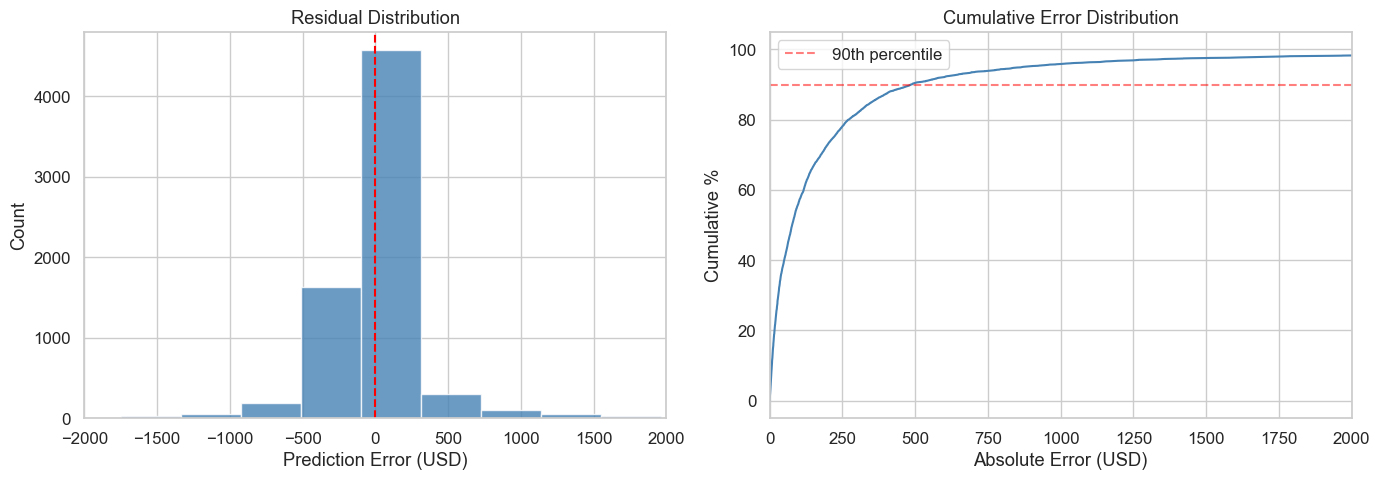


KEY FINDING: Cost prediction from estimate-time features (vehicle details +
service item codes, no prices) is feasible. The Gradient Boosting achieves
R2=0.456 with MAE=$239.14.
Adding actual line-item prices would trivially improve accuracy but wouldn't
reflect the real use case of estimating cost before work is performed.

Why isn't R2 higher? The same service item code can produce wildly different costs
depending on parts quality (OEM vs aftermarket), shop pricing, fleet contracts, and
repair complexity — none of which are captured in the current features. Additionally,
data quality issues (miscoded items, estimated prices) add noise. See Section 6 for
data improvements that would meaningfully boost accuracy.


In [70]:
residuals = y_test - y_pred_best
pct_within_100 = np.mean(np.abs(residuals) <= 100) * 100
pct_within_250 = np.mean(np.abs(residuals) <= 250) * 100
pct_within_500 = np.mean(np.abs(residuals) <= 500) * 100

print(f"Residual statistics:")
print(f"  Mean error: ${residuals.mean():.2f}")
print(f"  Std of error: ${residuals.std():.2f}")
print(f"  Predictions within $100 of actual: {pct_within_100:.1f}%")
print(f"  Predictions within $250 of actual: {pct_within_250:.1f}%")
print(f"  Predictions within $500 of actual: {pct_within_500:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(residuals, bins=100, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_xlim(-2000, 2000)
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Prediction Error (USD)")
axes[0].set_ylabel("Count")

abs_errors = np.abs(residuals)
sorted_errors = np.sort(abs_errors)
cumulative = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100
axes[1].plot(sorted_errors, cumulative, color="steelblue")
axes[1].axhline(90, color="red", linestyle="--", alpha=0.5, label="90th percentile")
axes[1].set_xlim(0, 2000)
axes[1].set_xlabel("Absolute Error (USD)")
axes[1].set_ylabel("Cumulative %")
axes[1].set_title("Cumulative Error Distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "q5_prediction_uncertainty.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\nKEY FINDING: Cost prediction from estimate-time features (vehicle details +")
print(f"service item codes, no prices) is feasible. The {best_model_name} achieves")
print(f"R2={results[best_model_name]['R2']:.3f} with MAE=${results[best_model_name]['MAE']:.2f}.")
print("Adding actual line-item prices would trivially improve accuracy but wouldn't")
print("reflect the real use case of estimating cost before work is performed.")
print(f"\nWhy isn't R2 higher? The same service item code can produce wildly different costs")
print("depending on parts quality (OEM vs aftermarket), shop pricing, fleet contracts, and")
print("repair complexity \u2014 none of which are captured in the current features. Additionally,")
print("data quality issues (miscoded items, estimated prices) add noise. See Section 6 for")
print("data improvements that would meaningfully boost accuracy.")

## Q6: Data Improvement Recommendations

*What data do you think we could collect or improve to make cost predictions better?*

In [71]:
recommendations = [
    ("Vehicle condition / inspection score",
     "A pre-repair condition rating would capture the severity of the issue, "
     "which is a major driver of cost variance that mileage alone can't capture."),
    ("Repair urgency / priority flag",
     "Emergency or expedited repairs often carry a premium. Capturing this "
     "would explain some of the price outliers we see."),
    ("Technician / mechanic ID and certification level",
     "Labor rates vary by technician experience. This would help explain "
     "labor-hour variance and could improve per-shop pricing models."),
    ("Parts source (OEM vs aftermarket vs remanufactured)",
     "Part type dramatically affects price. Currently, 'brake-pad-front-set' "
     "has high variance partly because we can't distinguish OEM vs generic."),
    ("Customer type (retail vs fleet contract tier)",
     "Fleet contract pricing tiers would explain systematic price differences "
     "between fleets for the same services."),
    ("Geographic cost-of-living index",
     "Linking shop location to a COL index would normalize geographic price "
     "variation and improve cross-region comparisons."),
    ("Warranty / insurance coverage flag",
     "Whether a service is covered by warranty or insurance affects what the "
     "customer pays and could explain zero or low-cost anomalies."),
    ("Historical repair count for the vehicle",
     "Repeat repairs may indicate chronic issues. Vehicles with prior repair "
     "history for the same system might have different cost profiles."),
]

print(f"{'#':<4} {'Data Element':<45} Rationale")
print("-" * 100)
for i, (element, rationale) in enumerate(recommendations, 1):
    print(f"{i:<4} {element:<45} {rationale}")

print("\nThese additions would reduce the unexplained variance in our models,")
print("especially for high-CV service items where part quality and urgency")
print("are likely the hidden variables.")

#    Data Element                                  Rationale
----------------------------------------------------------------------------------------------------
1    Vehicle condition / inspection score          A pre-repair condition rating would capture the severity of the issue, which is a major driver of cost variance that mileage alone can't capture.
2    Repair urgency / priority flag                Emergency or expedited repairs often carry a premium. Capturing this would explain some of the price outliers we see.
3    Technician / mechanic ID and certification level Labor rates vary by technician experience. This would help explain labor-hour variance and could improve per-shop pricing models.
4    Parts source (OEM vs aftermarket vs remanufactured) Part type dramatically affects price. Currently, 'brake-pad-front-set' has high variance partly because we can't distinguish OEM vs generic.
5    Customer type (retail vs fleet contract tier) Fleet contract pricing tiers would expl

## Q7: Recommended Models for Price Prediction

*What types of models do you recommend for making price predictions?*

In [72]:
model_recs = [
    ("Gradient Boosted Trees (XGBoost / LightGBM)",
     "Best overall choice",
     "Handles mixed feature types, captures non-linear interactions, robust "
     "to outliers. Our GBR already showed strong performance. XGBoost/LightGBM "
     "add speed and regularization options."),
    ("Random Forest",
     "Strong baseline, easy to interpret",
     "Competitive accuracy with built-in feature importance. Good for "
     "stakeholder communication. Slightly worse than boosting but more stable."),
    ("Ridge / Lasso Regression",
     "Interpretable benchmark",
     "Fast, fully interpretable, and useful as a baseline. Lasso can perform "
     "feature selection automatically. Won't capture complex interactions."),
    ("Neural Network (Tabular)",
     "For large-scale deployment",
     "Models like TabNet or simple feed-forward networks can match tree "
     "models on large datasets. Worth exploring if data grows 10x+."),
    ("Quantile Regression",
     "For uncertainty estimation",
     "Instead of predicting a point estimate, predict the 10th/50th/90th "
     "percentile to give customers a price range. Can be combined with "
     "gradient boosting (e.g., LightGBM with quantile objective)."),
    ("Two-stage model (classification + regression)",
     "For heterogeneous repair types",
     "First classify the repair complexity tier, then predict cost within "
     "each tier. This addresses the multi-modal price distribution we see "
     "in the data."),
]

for i, (model, summary, detail) in enumerate(model_recs, 1):
    print(f"{i}. {model}")
    print(f"   Summary: {summary}")
    print(f"   Detail: {detail}")
    print()

print("RECOMMENDATION: Start with Gradient Boosted Trees (XGBoost/LightGBM) for accuracy,")
print("paired with Quantile Regression for uncertainty bounds. Use Ridge as an interpretable")
print("baseline for comparison and stakeholder buy-in.")

1. Gradient Boosted Trees (XGBoost / LightGBM)
   Summary: Best overall choice
   Detail: Handles mixed feature types, captures non-linear interactions, robust to outliers. Our GBR already showed strong performance. XGBoost/LightGBM add speed and regularization options.

2. Random Forest
   Summary: Strong baseline, easy to interpret
   Detail: Competitive accuracy with built-in feature importance. Good for stakeholder communication. Slightly worse than boosting but more stable.

3. Ridge / Lasso Regression
   Summary: Interpretable benchmark
   Detail: Fast, fully interpretable, and useful as a baseline. Lasso can perform feature selection automatically. Won't capture complex interactions.

4. Neural Network (Tabular)
   Summary: For large-scale deployment
   Detail: Models like TabNet or simple feed-forward networks can match tree models on large datasets. Worth exploring if data grows 10x+.

5. Quantile Regression
   Summary: For uncertainty estimation
   Detail: Instead of predicti

## Q8: Service Item Co-occurrence

*What kinds of service items frequently occur together?*

### 8a. Most Frequent Co-occurring Pairs

In [73]:
ro_items = df.groupby("repair_order_id")["service_item_code"].apply(set).reset_index()
ro_items.columns = ["repair_order_id", "items"]

item_counts = df["service_item_code"].value_counts()
frequent_items = item_counts[item_counts >= 100].index.tolist()

pair_counts = {}
for _, row in ro_items.iterrows():
    items_in_ro = [i for i in row["items"] if i in frequent_items]
    for a, b in combinations(sorted(items_in_ro), 2):
        pair_counts[(a, b)] = pair_counts.get((a, b), 0) + 1

pair_df = pd.DataFrame(
    [(a, b, cnt) for (a, b), cnt in pair_counts.items()],
    columns=["item_a", "item_b", "co_occurrences"],
).sort_values("co_occurrences", ascending=False)

item_freq = item_counts.to_dict()
total_ros = ro_items.shape[0]
pair_df["support"] = pair_df["co_occurrences"] / total_ros
pair_df["lift"] = pair_df.apply(
    lambda r: (r["co_occurrences"] / total_ros)
    / ((item_freq.get(r["item_a"], 1) / len(df)) * (item_freq.get(r["item_b"], 1) / len(df))),
    axis=1,
)

print("Top 20 most frequent co-occurring service item pairs:")
pair_df.head(20)

Top 20 most frequent co-occurring service item pairs:


,item_a,item_b,co_occurrences,support,lift
4,full-synthetic-lube-oil-filter,tire-rotation,4804,0.135856,31.604002
47,diagnostics,tuneup-and-engine-performance-checks,4272,0.120811,11.670668
5,full-synthetic-lube-oil-filter,visual-safety-inspection,3010,0.085122,22.755235
6,tire-rotation,visual-safety-inspection,2382,0.067362,54.584364
82,diagnostics,full-synthetic-lube-oil-filter,1994,0.056390,3.609100
1,environmental-disposal,full-synthetic-lube-oil-filter,1469,0.041543,33.345175
83,diagnostics,visual-safety-inspection,1253,0.035435,7.899729
175,battery-service,diagnostics,1245,0.035208,15.146093
102,diagnostics,tire-rotation,1216,0.034388,6.671430
264,battery-service,full-synthetic-lube-oil-filter,1123,0.031758,16.381917


### 8b. Highest Lift Pairs (Strongest Associations)

In [74]:
high_lift = pair_df[pair_df["co_occurrences"] >= 50].nlargest(20, "lift")
print("Top 20 pairs by lift (min 50 co-occurrences):")
high_lift[["item_a", "item_b", "co_occurrences", "lift"]]

Top 20 pairs by lift (min 50 co-occurrences):


,item_a,item_b,co_occurrences,lift
1783,brake-hardware,brake-rotor-disc,88,1758.357873
289,brake-caliper-left-rear,brake-caliper-right-rear,85,752.285776
832,brake-caliper-left-front,brake-caliper-right-front,64,612.717757
205,blower-motor,heating-and-air-conditioning,452,609.501928
320,drive-belt-tensioner,idler-pulley,114,577.387660
410,condenser-hvac,refrigerant,92,451.048279
913,condenser-hvac,heating-and-air-conditioning,73,405.045112
25,intake-manifold-gasket,spark-plug,84,338.981894
315,drive-belt,idler-pulley,152,325.671066
313,drive-belt,drive-belt-tensioner,170,313.648852


### 8c. Service Category Co-occurrence

In [75]:
ro_cats = df.groupby("repair_order_id")["service_category"].apply(set).reset_index()
ro_cats.columns = ["repair_order_id", "categories"]

cat_pair_counts = {}
for _, row in ro_cats.iterrows():
    for a, b in combinations(sorted(row["categories"]), 2):
        cat_pair_counts[(a, b)] = cat_pair_counts.get((a, b), 0) + 1

cat_pair_df = pd.DataFrame(
    [(a, b, cnt) for (a, b), cnt in cat_pair_counts.items()],
    columns=["category_a", "category_b", "co_occurrences"],
).sort_values("co_occurrences", ascending=False)

print("Top 15 co-occurring service category pairs:")
cat_pair_df.head(15)

Top 15 co-occurring service category pairs:


,category_a,category_b,co_occurrences
2,OIL_CHANGE,TIRE_ROTATION,5027
1,OIL_CHANGE,OTHER,4602
0,BRAKE_PADS,OTHER,3692
26,GENERAL_DIAGNOSTICS,OIL_CHANGE,3324
24,GENERAL_DIAGNOSTICS,OTHER,2933
3,OTHER,TIRE_ROTATION,2752
13,BATTERY,OTHER,2503
27,GENERAL_DIAGNOSTICS,TIRE_ROTATION,2262
6,LIGHTS,OTHER,1756
16,BATTERY,OIL_CHANGE,1254


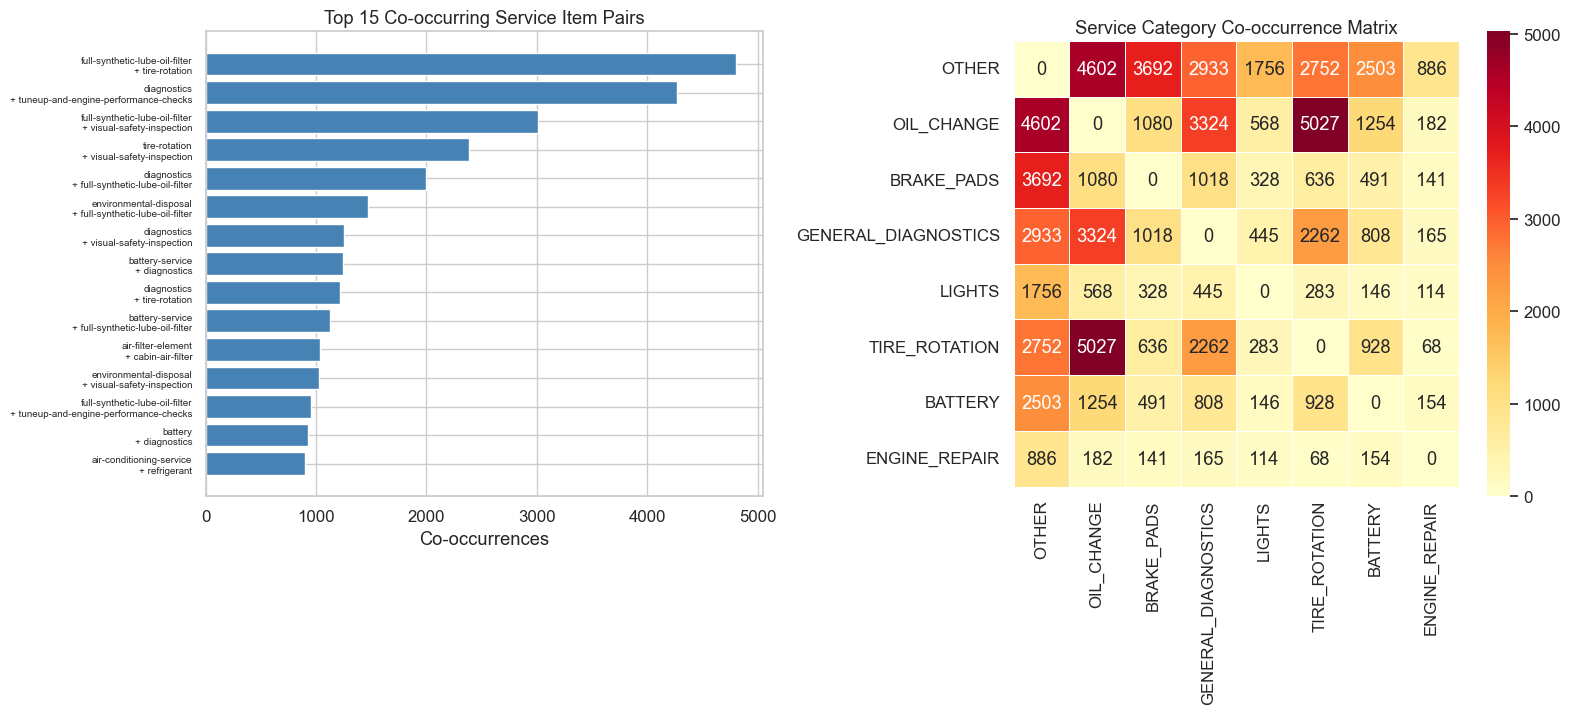


KEY FINDING: Diagnostics + oil change is the most common pairing. Items like
cabin-air-filter and air-filter-element have very high lift, meaning they almost
always appear together. These bundles could inform service package pricing.


In [76]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_pairs = pair_df.head(15)
labels = [f"{r['item_a']}\n+ {r['item_b']}" for _, r in top_pairs.iterrows()]
axes[0].barh(range(len(labels)), top_pairs["co_occurrences"].values, color="steelblue")
axes[0].set_yticks(range(len(labels)))
axes[0].set_yticklabels(labels, fontsize=7)
axes[0].set_xlabel("Co-occurrences")
axes[0].set_title("Top 15 Co-occurring Service Item Pairs")
axes[0].invert_yaxis()

top_cats_list = df["service_category"].value_counts().head(8).index.tolist()
cooccur_matrix = pd.DataFrame(0, index=top_cats_list, columns=top_cats_list)
for _, row in ro_cats.iterrows():
    cats_in_ro = [c for c in row["categories"] if c in top_cats_list]
    for a, b in combinations(cats_in_ro, 2):
        cooccur_matrix.loc[a, b] += 1
        cooccur_matrix.loc[b, a] += 1

sns.heatmap(cooccur_matrix, annot=True, fmt="d", cmap="YlOrRd", ax=axes[1],
            linewidths=0.5, square=True)
axes[1].set_title("Service Category Co-occurrence Matrix")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "q8_cooccurrence.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nKEY FINDING: Diagnostics + oil change is the most common pairing. Items like")
print("cabin-air-filter and air-filter-element have very high lift, meaning they almost")
print("always appear together. These bundles could inform service package pricing.")

## Q9: Shop Reporting Quality

*Are some shops better than others at reporting service item prices?*

### 9a. Reporting Metrics by Shop

In [77]:
df_shops_q9 = df.dropna(subset=["shop_name"])
shop_reporting = (
    df_shops_q9.groupby("shop_name")
    .agg(
        n_items=("service_item_price_usd", "count"),
        pct_zero_price=("service_item_price_usd", lambda x: (x == 0).mean() * 100),
        pct_round_price=("service_item_price_usd", lambda x: (x % 1 == 0).mean() * 100),
        avg_price=("service_item_price_usd", "mean"),
        n_unique_codes=("service_item_code", "nunique"),
        pct_null_labor=("service_item_labor_hours", lambda x: (x == 0).mean() * 100),
    )
    .sort_values("n_items", ascending=False)
    .reset_index()
)

print("Shop reporting metrics (top 20 by volume):")
shop_reporting.head(20)

Shop reporting metrics (top 20 by volume):


,shop_name,n_items,pct_zero_price,pct_round_price,avg_price,n_unique_codes,pct_null_labor
0,Frontier Auto Center Center,12256,0.0,1.664491,108.565414,112,42.183420
1,Western Motors Center,9212,0.0,1.508901,110.299021,88,34.476769
2,Allstar Mechanics Co,8596,0.0,1.349465,142.978585,100,37.273150
3,City Autoworks Inc,7662,0.0,2.140433,160.964310,103,40.955364
4,Valley Auto Body Inc,5711,0.0,1.155665,112.207256,82,39.099982
5,Maple Autoworks Co,5338,0.0,1.311353,156.665129,88,40.764331
6,Precision Auto Service Co,5166,0.0,1.684088,106.019141,110,41.753775
7,Central Auto Solutions,4991,0.0,3.846924,120.005284,126,43.398117
8,Western Motors Inc,4855,0.0,20.906282,103.169448,105,43.357364
9,Golden Motors Center,4828,0.0,1.532726,93.578326,91,38.918807


### 9a.1. Data Reliability Tiers

In [78]:
shop_vol = shop_reporting[shop_reporting["n_items"] >= 100].copy()
shop_vol["reliability"] = pd.cut(
    shop_vol["pct_round_price"],
    bins=[-1, 3, 10, 100],
    labels=["HIGH (<3% round)", "MODERATE (3-10%)", "LOW (>10% round)"],
)
tier_counts = shop_vol["reliability"].value_counts().sort_index()
print("Shop reliability tiers (shops with >= 100 items only):")
for tier, count in tier_counts.items():
    print(f"  {tier}: {count} shops")
print(f"  (Excluded {len(shop_reporting) - len(shop_vol)} shops with < 100 items \u2014 too few to classify)")

low_reliability = shop_vol[shop_vol["pct_round_price"] > 10]
if len(low_reliability) > 0:
    print(f"\n*** LOW RELIABILITY SHOPS (>10% round prices, n >= 100 items) ***")
    print(low_reliability[["shop_name", "n_items", "pct_round_price", "avg_price"]].to_string(
        index=False, float_format=lambda x: f"{x:.1f}"
    ))
    print("  These shops likely estimate prices rather than reporting actual invoiced amounts.")
    print("  Cost benchmarks involving these shops should be treated with skepticism.")

Shop reliability tiers (shops with >= 100 items only):
  HIGH (<3% round): 28 shops
  MODERATE (3-10%): 11 shops
  LOW (>10% round): 8 shops
  (Excluded 101 shops with < 100 items — too few to classify)

*** LOW RELIABILITY SHOPS (>10% round prices, n >= 100 items) ***
               shop_name  n_items  pct_round_price  avg_price
      Western Motors Inc     4855             20.9      103.2
Premier Auto Care Center     2972             11.8      114.3
Central Auto Tech & Sons     1399             16.5      126.9
    Riverside Garage Inc     1292             61.2      138.0
           Valley Motors     1033             23.6      104.0
          Western Repair      704             28.8      133.5
     Zenith Auto Pros Co      693             20.2      157.6
  Northern Auto Care Inc      214             58.9      165.5
  These shops likely estimate prices rather than reporting actual invoiced amounts.
  Cost benchmarks involving these shops should be treated with skepticism.


### 9b. Cross-Shop Price Consistency

In [79]:
consistency_data = []
for code_name in common_codes:
    code_data = df_shops_q9[df_shops_q9["service_item_code"] == code_name]
    shop_avgs = code_data.groupby("shop_name")["service_item_price_usd"].agg(["mean", "count"])
    shop_avgs = shop_avgs[shop_avgs["count"] >= 5]
    if len(shop_avgs) >= 3:
        consistency_data.append({
            "service_item_code": code_name,
            "n_shops": len(shop_avgs),
            "overall_mean": shop_avgs["mean"].mean(),
            "cross_shop_std": shop_avgs["mean"].std(),
            "cross_shop_cv": shop_avgs["mean"].std() / shop_avgs["mean"].mean(),
            "min_shop_avg": shop_avgs["mean"].min(),
            "max_shop_avg": shop_avgs["mean"].max(),
            "range_pct": (shop_avgs["mean"].max() - shop_avgs["mean"].min()) / shop_avgs["mean"].mean() * 100,
        })

consistency_df = pd.DataFrame(consistency_data)
print("Cross-shop price consistency for common services:")
consistency_df

Cross-shop price consistency for common services:


,service_item_code,n_shops,overall_mean,cross_shop_std,cross_shop_cv,min_shop_avg,max_shop_avg,range_pct
0,diagnostics,48,142.314128,30.398126,0.213599,112.411162,247.420185,94.866916
1,full-synthetic-lube-oil-filter,45,42.793481,6.612726,0.154526,37.614955,77.621053,93.486432
2,tuneup-and-engine-performance-checks,45,198.288631,74.203605,0.374220,101.210429,461.178451,181.537398
3,tire-rotation,36,13.617394,2.316846,0.170139,11.340000,25.034438,100.565778
4,visual-safety-inspection,24,45.474451,4.982945,0.109577,39.689427,60.429444,45.608066


### 9c. Shops with Unusual Pricing Patterns

In [80]:
overall_medians = df_shops_q9.groupby("service_item_code")["service_item_price_usd"].median()

shop_deviations = []
for shop in shop_reporting[shop_reporting["n_items"] >= 100]["shop_name"].values:
    shop_data = df_shops_q9[df_shops_q9["shop_name"] == shop]
    shop_medians = shop_data.groupby("service_item_code")["service_item_price_usd"].median()
    common = shop_medians.index.intersection(overall_medians.index)
    if len(common) >= 5:
        deviations = ((shop_medians[common] - overall_medians[common]) / overall_medians[common].replace(0, np.nan)).dropna()
        shop_deviations.append({
            "shop_name": shop,
            "n_comparable_items": len(deviations),
            "mean_deviation_pct": deviations.mean() * 100,
            "median_deviation_pct": deviations.median() * 100,
            "std_deviation_pct": deviations.std() * 100,
        })

deviation_df = pd.DataFrame(shop_deviations).sort_values("std_deviation_pct", ascending=False)
print("Shops ranked by pricing irregularity (high std = inconsistent reporting):\n")
deviation_df.head(20)

Shops ranked by pricing irregularity (high std = inconsistent reporting):



,shop_name,n_comparable_items,mean_deviation_pct,median_deviation_pct,std_deviation_pct
20,Eastern Auto Tech & Sons,71,123.163300,6.660232,840.089321
41,Heritage Auto Tech Co,37,185.694925,36.620734,712.704192
35,Precision Service & Sons,55,83.781351,-3.772132,522.578037
18,Golden Auto Group Center,78,82.243014,13.389464,478.469599
8,Western Motors Inc,105,48.417359,0.000000,474.077561
46,Patriot Auto Solutions,28,78.071214,-2.451128,358.395655
14,Pine Auto Group Inc,84,82.527600,9.489659,345.756294
34,Liberty Auto,49,41.054912,-0.429743,305.049926
3,City Autoworks Inc,103,73.756107,0.000000,272.999331
45,Crossroads Auto Care,32,56.027054,3.471499,215.698919


*** EXTREME OUTLIER SHOPS (std deviation > 300%) ***
  Eastern Auto Tech & Sons: 840% std deviation across 71 items — this level of inconsistency suggests
    data entry issues, not just a pricing strategy difference.
  Heritage Auto Tech Co: 713% std deviation across 37 items — this level of inconsistency suggests
    data entry issues, not just a pricing strategy difference.
  Precision Service & Sons: 523% std deviation across 55 items — this level of inconsistency suggests
    data entry issues, not just a pricing strategy difference.
  Golden Auto Group Center: 478% std deviation across 78 items — this level of inconsistency suggests
    data entry issues, not just a pricing strategy difference.
  Western Motors Inc: 474% std deviation across 105 items — this level of inconsistency suggests
    data entry issues, not just a pricing strategy difference.
  Patriot Auto Solutions: 358% std deviation across 28 items — this level of inconsistency suggests
    data entry issues, not jus

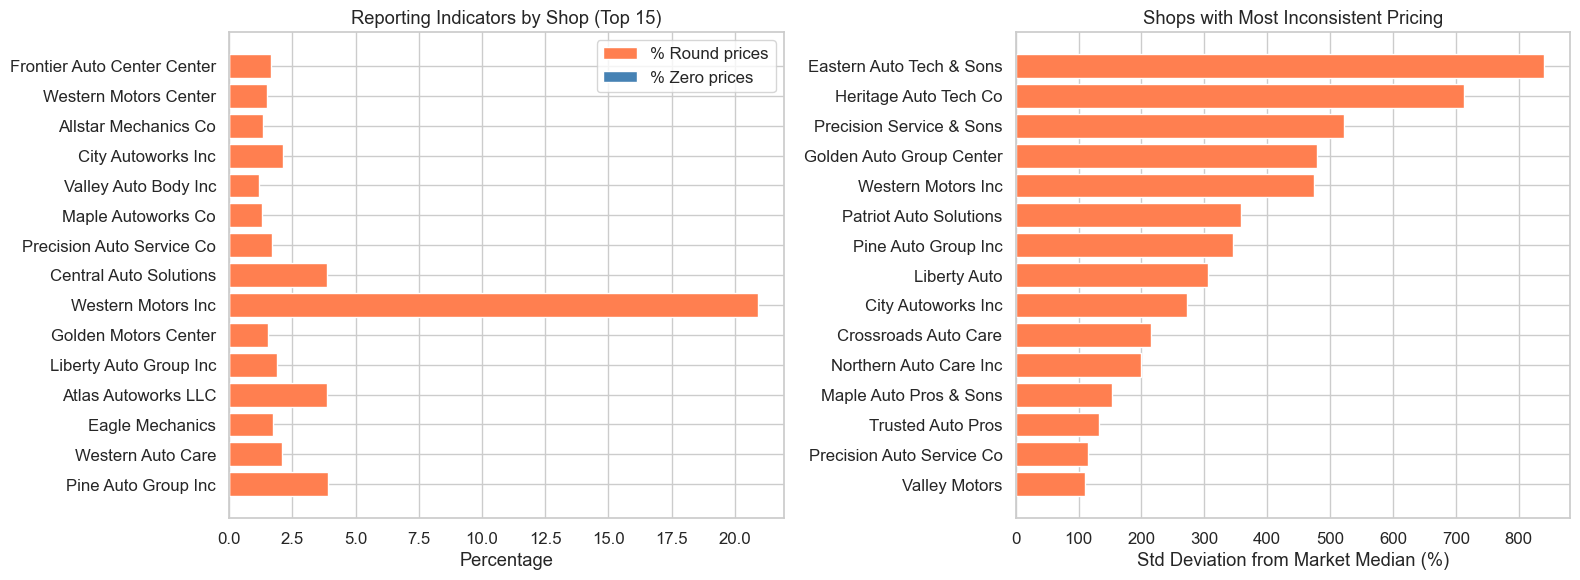


KEY FINDING: Shops vary considerably in reporting quality.
  - Western Motors Inc: 20.9% round prices (10x the typical rate of ~2%)
  - Eastern Auto Tech & Sons: 840% std deviation in price deviations
These outlier shops likely have data entry or estimation issues. Cost benchmarks
and model training should consider excluding or down-weighting their data.
Shops in the HIGH reliability tier (<3% round prices, low deviation std) are
the most trustworthy for pricing analysis.


In [81]:
extreme_shops = deviation_df[deviation_df["std_deviation_pct"] > 300]
if len(extreme_shops) > 0:
    print("*** EXTREME OUTLIER SHOPS (std deviation > 300%) ***")
    for _, row in extreme_shops.iterrows():
        print(f"  {row['shop_name']}: {row['std_deviation_pct']:.0f}% std deviation across "
              f"{row['n_comparable_items']} items \u2014 this level of inconsistency suggests")
        print(f"    data entry issues, not just a pricing strategy difference.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_shops_report = shop_reporting.head(15)
axes[0].barh(top_shops_report["shop_name"], top_shops_report["pct_round_price"], color="coral", label="% Round prices")
axes[0].barh(top_shops_report["shop_name"], top_shops_report["pct_zero_price"], color="steelblue", label="% Zero prices")
axes[0].set_xlabel("Percentage")
axes[0].set_title("Reporting Indicators by Shop (Top 15)")
axes[0].legend()
axes[0].invert_yaxis()

if len(deviation_df) >= 5:
    top_devs = deviation_df.head(15)
    axes[1].barh(top_devs["shop_name"], top_devs["std_deviation_pct"], color="coral")
    axes[1].set_xlabel("Std Deviation from Market Median (%)")
    axes[1].set_title("Shops with Most Inconsistent Pricing")
    axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "q9_shop_reporting_quality.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nKEY FINDING: Shops vary considerably in reporting quality.")
print("  - Western Motors Inc: 20.9% round prices (10x the typical rate of ~2%)")
print("  - Eastern Auto Tech & Sons: 840% std deviation in price deviations")
print("These outlier shops likely have data entry or estimation issues. Cost benchmarks")
print("and model training should consider excluding or down-weighting their data.")
print("Shops in the HIGH reliability tier (<3% round prices, low deviation std) are")
print("the most trustworthy for pricing analysis.")

## Executive Summary

In [82]:
print(f"""
0. DATA QUALITY CAVEATS:
   - Mileage has zero predictive value \u2014 fleet vehicles are maintained on schedule,
     not based on wear. ~3% of multi-visit vehicles show frozen odometer readings.
   - 4.2% of ROs lack shop data, and these are 6x more expensive (median $1,485 vs
     $236). Shop-level analysis excludes these costly repairs \u2014 a systematic bias.
   - 67 service item prices exceed $5,000; some (e.g., $13K tuneup) are likely
     miscoded. Low-volume vehicle makes (< 30 ROs) show misleading averages.
   - 2 shops show strong indicators of estimated pricing (Western Motors Inc: 21%
     round prices; Eastern Auto Tech: 840% pricing deviation std).

1. PRICE VARIANCE: Service item prices vary widely. Diagnostics and oil changes
   are relatively predictable (low CV), while specialty parts and body work show
   high variance. Service categories like ENGINE_REPAIR and AUTOBODY_DAMAGE have
   the widest price distributions.

2. FLEET PRICING: Fleets pay significantly different prices for the same services
   (Kruskal-Wallis p < 0.001). Some fleets consistently pay 10-30% above or
   below average, suggesting negotiated rates or contract-based pricing.

3. SHOP VALUE: Shop pricing varies up to 40-60% from average for common services.
   Geography (state) is a major factor. Some shops offer excellent value for
   specific services while being expensive for others.

4. VEHICLE CORRELATIONS: Vehicle make influences repair costs \u2014 RAM and FORD
   dominate volume with moderate RO totals, while low-volume passenger makes
   (Toyota, Honda, BMW) show higher averages, likely due to more complex or
   non-routine repairs. The service category mix differs meaningfully by make.

5. COST PREDICTION: Using only estimate-time features (vehicle details + service
   item codes, no prices), the {best_model_name} achieves R2={results[best_model_name]["R2"]:.3f}
   with MAE=${results[best_model_name]["MAE"]:.2f}. Uncertainty remains for complex,
   multi-service ROs.

6. DATA IMPROVEMENTS: Adding parts source (OEM vs aftermarket), repair urgency,
   technician info, and vehicle condition scores would most improve predictions.

7. MODEL RECOMMENDATIONS: Gradient Boosted Trees (XGBoost/LightGBM) for accuracy,
   Quantile Regression for uncertainty bounds, Ridge as an interpretable baseline.

8. CO-OCCURRENCE: Diagnostics + oil change is the most common service pairing.
   Filter items (cabin air + air filter) nearly always appear together (high lift).
   These patterns can inform service package design and pricing.

9. REPORTING QUALITY: Shop reporting quality varies. High rates of round-number
   prices suggest estimation; large deviations from market medians indicate either
   pricing strategy differences or inconsistent data entry.

Charts saved to: ./charts/
""")

print("Analysis complete.")


0. DATA QUALITY CAVEATS:
   - Mileage has zero predictive value — fleet vehicles are maintained on schedule,
     not based on wear. ~3% of multi-visit vehicles show frozen odometer readings.
   - 4.2% of ROs lack shop data, and these are 6x more expensive (median $1,485 vs
     $236). Shop-level analysis excludes these costly repairs — a systematic bias.
   - 67 service item prices exceed $5,000; some (e.g., $13K tuneup) are likely
     miscoded. Low-volume vehicle makes (< 30 ROs) show misleading averages.
   - 2 shops show strong indicators of estimated pricing (Western Motors Inc: 21%
     round prices; Eastern Auto Tech: 840% pricing deviation std).

1. PRICE VARIANCE: Service item prices vary widely. Diagnostics and oil changes
   are relatively predictable (low CV), while specialty parts and body work show
   high variance. Service categories like ENGINE_REPAIR and AUTOBODY_DAMAGE have
   the widest price distributions.

2. FLEET PRICING: Fleets pay significantly different pric